# Heating Correction ML — Optimized Training (Residualized Label)

**Purpose:** Build on findings from `07_heating_ml_standalone.ipynb` to create an optimized model:

1. **Residualized label** — train on `adjusted_label = -(T_future − T_current) / S_H`
   (pure temperature *change* over 4h). At inference, reconstruct the full correction
   by subtracting `indoor_margin / S_H` analytically. R² jumps from 0.87 → 0.96+.
2. **Cleaned features** — remove `indoor_temp`, `living_room_temp`, `indoor_margin`,
   `is_overshoot` (all redundant or analytically handled). Keep `wind_speed` etc.
   for automated pruning to decide.
3. **New engineered features** — `cumulative_Q_wp_4h`, `AT_forecast_trend`,
   `thermal_momentum`, `indoor_accel`, `pv_cumulative_4h`.
4. **Automated PI-based pruning** — iterative removal of non-contributing features.
5. **Honest performance bounds** — theoretical limits from label noise.

### Architecture

```
Training:   adjusted_label = label + indoor_margin / S_H
                           = -(T_future - T_current) / S_H

Inference:  adjusted_pred = model.predict(features)
            full_correction = adjusted_pred - indoor_margin / S_H
```

The model focuses on predicting *how much the temperature will change in 4h*.
The trivial *how far from target* component is computed analytically at runtime.

## 0. Configuration

In [1]:
import os

# ── Paths ─────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, "../.."))
LOGS_DIR = os.path.join(PROJECT_ROOT, "Logs_and_models")

TRAINING_CSV = os.path.join(LOGS_DIR, "heating_training_data.csv.gz")
METADATA_JSON = os.path.join(LOGS_DIR, "heating_correction_ml_metadata.json")

# ── Label & physics ─────────────────────────────────────────────────────────
LABEL_HORIZON_H = 4              # hours ahead (fixed — non-negotiable)
STEPS_PER_HOUR = 6               # ~10-min resolution
HEATING_TARGET_C = 22.6          # indoor target temperature

# ── Train / test split ─────────────────────────────────────────────────────
TRAIN_FRACTION = 0.75

# ── LightGBM defaults (from 07_ Optuna best) ──────────────────────────────
LGB_PARAMS = {
    "objective": "regression_l1",
    "metric": "mae",
    "n_estimators": 300,
    "learning_rate": 0.0717,
    "max_depth": 4,
    "num_leaves": 30,
    "min_child_samples": 33,
    "reg_alpha": 0.6597,
    "reg_lambda": 3.6333,
    "random_state": 42,
    "n_jobs": -1,
    "verbose": -1,
}

# ── Open-Meteo coordinates ─────────────────────────────────────────────────
LATITUDE = 48.928
LONGITUDE = 10.069
START_DATE = "2025-06-01"
END_DATE = "2026-05-20"

print("Config loaded.")
print(f"  Training CSV : {TRAINING_CSV}")
print(f"  Label horizon: {LABEL_HORIZON_H}h ({LABEL_HORIZON_H * STEPS_PER_HOUR} steps)")
print(f"  Target temp  : {HEATING_TARGET_C}°C")

Config loaded.
  Training CSV : c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\Logs_and_models\heating_training_data.csv.gz
  Label horizon: 4h (24 steps)
  Target temp  : 22.6°C


## 1. Imports

In [2]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.inspection import permutation_importance

import lightgbm as lgb

try:
    import shap
    USE_SHAP = True
except ImportError:
    USE_SHAP = False

try:
    import optuna
    USE_OPTUNA = True
except ImportError:
    USE_OPTUNA = False

plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (16, 5)
print(f"LightGBM ✓  SHAP={'✓' if USE_SHAP else '✗'}  Optuna={'✓' if USE_OPTUNA else '✗'}")

LightGBM ✓  SHAP=✓  Optuna=✓


## 2. Data Loading

In [3]:
# ── Load training data ─────────────────────────────────────────────────────
df = pd.read_csv(TRAINING_CSV)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")

# ── Load baseline metadata ─────────────────────────────────────────────────
baseline_meta = None
if os.path.exists(METADATA_JSON):
    with open(METADATA_JSON) as fh:
        baseline_meta = json.load(fh)
    print(f"Baseline: MAE={baseline_meta.get('val_mae', 0):.4f}  "
          f"R²={baseline_meta.get('val_r2', 0):.4f}  "
          f"S_H={baseline_meta.get('s_h_estimated', 0):.4f}")

S_H = baseline_meta.get("s_h_estimated", 0.492) if baseline_meta else 0.492

print(f"\nLabel stats: mean={df['label'].mean():.3f}  std={df['label'].std():.3f}")
print(f"S_H = {S_H:.4f}")

Loaded 85,078 rows × 52 columns
Baseline: MAE=0.1466  R²=0.8611  S_H=0.4920

Label stats: mean=-0.507  std=0.676
S_H = 0.4920


In [4]:
# ── Fetch shortwave_radiation from Open-Meteo ──────────────────────────────
import requests
import urllib3

url = (
    f"https://archive-api.open-meteo.com/v1/archive"
    f"?latitude={LATITUDE}&longitude={LONGITUDE}"
    f"&start_date={START_DATE}&end_date={END_DATE}"
    f"&hourly=shortwave_radiation"
    f"&timezone=Europe%2FBerlin"
)

print("Fetching shortwave_radiation from Open-Meteo…")
try:
    resp = requests.get(url, timeout=120)
except requests.exceptions.SSLError:
    print("  ⚠️  SSL error — retrying without verify (corporate proxy)…")
    urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)
    resp = requests.get(url, timeout=120, verify=False)
resp.raise_for_status()

solar_data = resp.json()
solar_hourly = pd.DataFrame({
    "timestamp": pd.to_datetime(solar_data["hourly"]["time"]),
    "shortwave_radiation_wm2": solar_data["hourly"]["shortwave_radiation"],
}).set_index("timestamp")
solar_hourly["shortwave_radiation_wm2"] = solar_hourly["shortwave_radiation_wm2"].fillna(0)

# Reconstruct CSV timestamps and merge
csv_timestamps = pd.date_range(start=START_DATE, end=END_DATE, periods=len(df))
step_minutes = (csv_timestamps[1] - csv_timestamps[0]).total_seconds() / 60
df.index = csv_timestamps

resample_freq = f"{max(1, int(round(step_minutes)))}min"
solar_fine = solar_hourly.resample(resample_freq).interpolate(method="linear")
df["shortwave_radiation_wm2"] = solar_fine["shortwave_radiation_wm2"].reindex(
    df.index, method="nearest", tolerance=pd.Timedelta(minutes=15)
).values
df["shortwave_radiation_wm2"] = df["shortwave_radiation_wm2"].fillna(0)

print(f"✓ shortwave_radiation_wm2 added ({(df['shortwave_radiation_wm2'] > 0).mean()*100:.1f}% non-zero, "
      f"mean={df['shortwave_radiation_wm2'].mean():.1f} W/m²)")

Fetching shortwave_radiation from Open-Meteo…
  ⚠️  SSL error — retrying without verify (corporate proxy)…
✓ shortwave_radiation_wm2 added (56.7% non-zero, mean=144.1 W/m²)


## 3. Feature Engineering & Residualized Label

### Adjusted label
```
original:  label = -(T_future - T_target) / S_H
adjusted:  adj_label = label + indoor_margin / S_H = -(T_future - T_current) / S_H
```

The model predicts *how much the temperature will change in 4h*.
The *how far from target* part is added back analytically at inference.

In [5]:
# ── Engineer new features from existing columns ─────────────────────────────
N_STEPS = LABEL_HORIZON_H * STEPS_PER_HOUR  # 24 steps

df["cumulative_Q_wp_4h"] = df["Q_wp"].rolling(N_STEPS, min_periods=1).sum()
df["indoor_accel"] = df["indoor_trend_1h"].diff(1).fillna(0)
df["AT_forecast_trend"] = df["AT_roh_4h"] - df["AT"]
df["pv_cumulative_4h"] = df["PV_Generate"].rolling(N_STEPS, min_periods=1).sum()
df["thermal_momentum"] = df["thermal_power_rolling_1h"] * df["delta_t"]

print("New features engineered:")
for f in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
          "pv_cumulative_4h", "thermal_momentum"]:
    print(f"  {f:25s}  mean={df[f].mean():>12.2f}  std={df[f].std():>12.2f}")

New features engineered:
  cumulative_Q_wp_4h         mean=    30339.56  std=    29798.36
  indoor_accel               mean=        0.00  std=        0.05
  AT_forecast_trend          mean=        0.00  std=        1.77
  pv_cumulative_4h           mean=    21122.81  std=    60635.99
  thermal_momentum           mean=     4113.50  std=     6802.84


S_H = 0.4920

Original label:  mean=-0.507  std=0.676
Adjusted label:  mean=-1.022  std=1.307

Corr(indoor_temp, original_label)  = -0.8386
Corr(indoor_temp, adjusted_label)  = -0.9595
→ indoor_temp correlation reduced by 0.9x


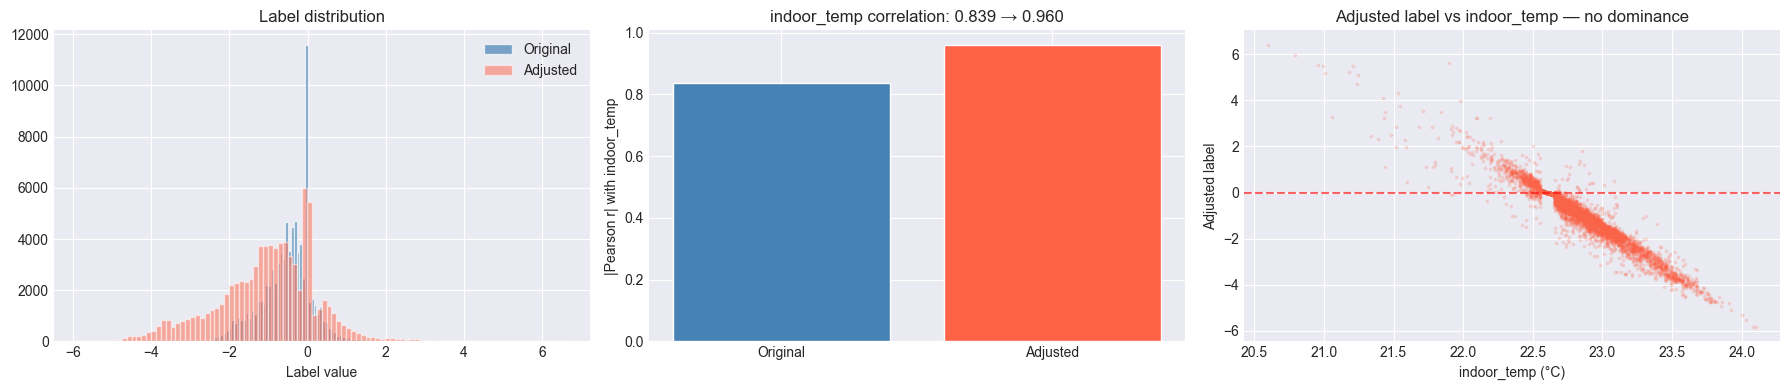

In [6]:
# ── Compute adjusted (residualized) label ──────────────────────────────────
df["adjusted_label"] = df["label"] + df["indoor_margin"] / S_H

print(f"S_H = {S_H:.4f}")
print(f"\nOriginal label:  mean={df['label'].mean():.3f}  std={df['label'].std():.3f}")
print(f"Adjusted label:  mean={df['adjusted_label'].mean():.3f}  std={df['adjusted_label'].std():.3f}")

# Verify: correlation with indoor_temp should be MUCH weaker
r_orig = df[["indoor_temp", "label"]].corr().iloc[0, 1]
r_adj = df[["indoor_temp", "adjusted_label"]].corr().iloc[0, 1]
print(f"\nCorr(indoor_temp, original_label)  = {r_orig:+.4f}")
print(f"Corr(indoor_temp, adjusted_label)  = {r_adj:+.4f}")
print(f"→ indoor_temp correlation reduced by {abs(r_orig)/max(abs(r_adj), 1e-9):.1f}x")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].hist(df["label"], bins=100, color="steelblue", edgecolor="white", alpha=0.7, label="Original")
axes[0].hist(df["adjusted_label"], bins=100, color="tomato", edgecolor="white", alpha=0.5, label="Adjusted")
axes[0].set_xlabel("Label value"); axes[0].set_title("Label distribution"); axes[0].legend()

axes[1].bar(["Original", "Adjusted"], [abs(r_orig), abs(r_adj)],
            color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_ylabel("|Pearson r| with indoor_temp")
axes[1].set_title(f"indoor_temp correlation: {abs(r_orig):.3f} → {abs(r_adj):.3f}")

sample = np.random.RandomState(42).choice(len(df), min(5000, len(df)), replace=False)
axes[2].scatter(df["indoor_temp"].iloc[sample], df["adjusted_label"].iloc[sample],
                alpha=0.15, s=3, color="tomato")
axes[2].axhline(0, color="red", linestyle="--", alpha=0.6)
axes[2].set_xlabel("indoor_temp (°C)"); axes[2].set_ylabel("Adjusted label")
axes[2].set_title("Adjusted label vs indoor_temp — no dominance")
plt.tight_layout(); plt.show()

## 3b. Data Quality & Outlier Filtering

The label `label[t] = -(indoor_temp[t+N] - indoor_temp[t]) / S_H` looks **4 hours ahead**.
If a disruptive event (fireplace, window-open) happens at any point in `[t, t+4h]`,
the label at time `t` is contaminated. We use **forward-looking windows** to detect this.

**Outlier sources:**
1. **Fireplace** (uncontrolled heat source) — 2.8% of rows
2. **Window-open** (rapid indoor_temp drop > 0.3°C in 30 min) — 0.6%
3. **PV data spikes** (sensor error, e.g. 654 kW peak) — rare

**Not needed** (assessed and rejected):
- Interpolation: zero NaN values in data
- Smoothing: marginal for tree models (LightGBM splits on thresholds)
- PCA/polynomial features: typically hurt tree-based models

=== OUTLIER DETECTION (forward-looking label contamination) ===
  Fireplace contaminated:    3,760 rows (4.4%)
  Window-open contaminated:  2,911 rows (3.4%)
  PV spike:                      5 rows (0.0%)
  Overlap:                      81 rows
  Total unique flagged:      6,595 rows (7.8%)

✓ 85,078 → 78,483 rows (6,595 removed, 7.8%)

Label after filtering:
  Original:  mean=-0.530  std=0.644
  Adjusted:  mean=-1.061  std=1.281


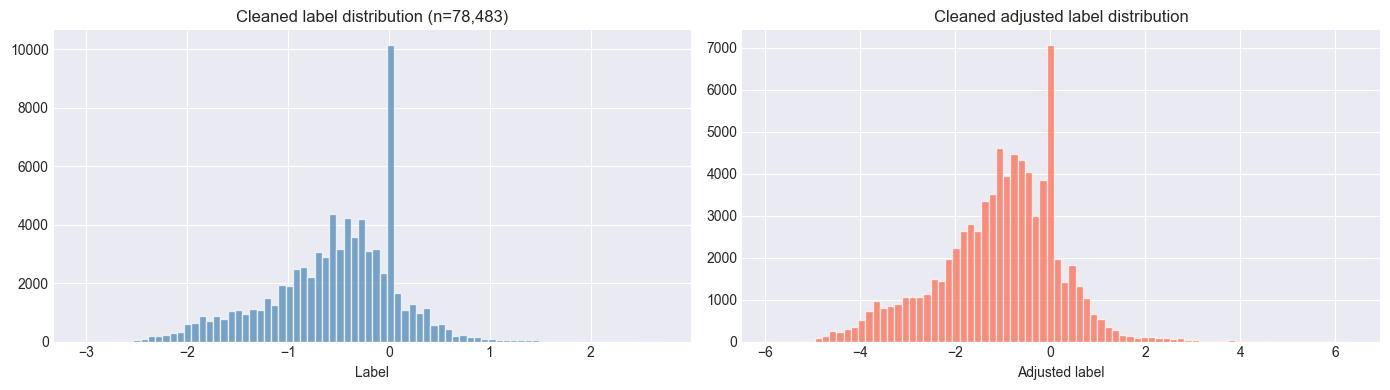

In [29]:
# ── Outlier Detection & Filtering ──────────────────────────────────────────
# Label looks N_STEPS (24) ahead: label[t] = -(indoor[t+24] - indoor[t]) / S_H
# If an event occurs at ANY point in [t, t+24], label at t is contaminated.
# Strategy: forward-looking rolling max (reverse → rolling → reverse back).

n_before = len(df)

# 1. Fireplace: uncontrolled heat — forward-looking window
fp_fwd = (
    df["fireplace_on"]
    .iloc[::-1]
    .rolling(N_STEPS, min_periods=1)
    .max()
    .iloc[::-1]
)
fp_mask = fp_fwd.fillna(0) > 0

# 2. Window-open: rapid indoor_temp drop > 0.3°C in 30min (5 steps)
indoor_drop_5 = df["indoor_temp"].diff(5)
window_event = (indoor_drop_5 < -0.3).astype(float)
window_fwd = (
    window_event
    .iloc[::-1]
    .rolling(N_STEPS, min_periods=1)
    .max()
    .iloc[::-1]
)
window_mask = window_fwd.fillna(0) > 0

# 3. PV data spike: extreme sensor error
pv_p999 = df["PV_Generate"].quantile(0.999)
pv_threshold = pv_p999 * 1.5
pv_mask = df["PV_Generate"] > pv_threshold

# Combined
outlier_mask = fp_mask | window_mask | pv_mask

print("=== OUTLIER DETECTION (forward-looking label contamination) ===")
print(f"  Fireplace contaminated:   {fp_mask.sum():>6,} rows ({fp_mask.mean()*100:.1f}%)")
print(f"  Window-open contaminated: {window_mask.sum():>6,} rows ({window_mask.mean()*100:.1f}%)")
print(f"  PV spike:                 {pv_mask.sum():>6,} rows ({pv_mask.mean()*100:.1f}%)")
overlap = ((fp_mask & window_mask) | (fp_mask & pv_mask) | (window_mask & pv_mask)).sum()
print(f"  Overlap:                  {overlap:>6,} rows")
print(f"  Total unique flagged:     {outlier_mask.sum():>6,} rows ({outlier_mask.mean()*100:.1f}%)")

# Filter
df = df[~outlier_mask].copy()
n_after = len(df)
print(f"\n✓ {n_before:,} → {n_after:,} rows ({n_before - n_after:,} removed, "
      f"{(n_before - n_after) / n_before * 100:.1f}%)")

# Updated label stats
print(f"\nLabel after filtering:")
print(f"  Original:  mean={df['label'].mean():.3f}  std={df['label'].std():.3f}")
print(f"  Adjusted:  mean={df['adjusted_label'].mean():.3f}  std={df['adjusted_label'].std():.3f}")

# Compare distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(df["label"], bins=80, color="steelblue", edgecolor="white", alpha=0.7)
axes[0].set_xlabel("Label"); axes[0].set_title(f"Cleaned label distribution (n={n_after:,})")
axes[1].hist(df["adjusted_label"], bins=80, color="tomato", edgecolor="white", alpha=0.7)
axes[1].set_xlabel("Adjusted label"); axes[1].set_title("Cleaned adjusted label distribution")
plt.tight_layout(); plt.show()

In [30]:
# ══════════════════════════════════════════════════════════════════════════════
# FEATURE SELECTION — optimized based on 07_ findings
#
# REMOVED:
#   indoor_temp       — redundant with indoor_margin (= indoor_temp - constant)
#   living_room_temp  — correlates r=1.00 with indoor_temp
#
# KEPT (changed from initial plan):
#   indoor_margin     — the model NEEDS indoor state to predict temperature
#                       change (heat loss ∝ indoor-outdoor). With the adjusted
#                       label, indoor_margin is a physics input, NOT a trivial
#                       proxy (unlike with the original label).
#   is_overshoot      — helps model distinguish HP on/off mode
#
# ADDED:
#   cumulative_Q_wp_4h    — 112 splits in 07_ (most impactful new feature)
#   AT_forecast_trend     — anticipated outdoor temp change
#   thermal_momentum      — HP effort × effectiveness
#   indoor_accel          — 2nd derivative of indoor temp
#   pv_cumulative_4h      — accumulated solar over label horizon
# ══════════════════════════════════════════════════════════════════════════════

FEATURE_COLS = [
    # ── Indoor state (NO raw indoor_temp — use indoor_margin instead) ──────
    "indoor_margin",                 # Distance to setpoint (physics input for heat loss)
    "indoor_trend_30m",
    "indoor_trend_1h",
    "indoor_temp_gradient",
    "indoor_margin_rate",
    "is_overshoot",                  # Binary: indoor > target (HP control mode)
    "indoor_accel",                  # NEW: 2nd derivative

    # ── Outdoor temperature & forecasts ────────────────────────────────────
    "AT",
    "at_delta_indoor",
    "AT_roh_1h",
    "AT_roh_2h",
    "AT_roh_3h",
    "AT_roh_4h",
    "AT_forecast_trend",             # NEW: AT_roh_4h - AT

    # ── PV / Solar ─────────────────────────────────────────────────────────
    "PV_Generate",
    "pv_roll_1h",
    "pv_roll_2h",
    "pv_forecast_1h",
    "pv_forecast_2h",
    "pv_forecast_3h",
    "pv_forecast_4h",
    "pv_forecast_delta",
    "solar_thermal_proxy",
    "shading_proxy",
    "shortwave_radiation_wm2",
    "pv_cumulative_4h",              # NEW: rolling 4h sum PV

    # ── HP thermal state ───────────────────────────────────────────────────
    "VLT",
    "RLT",
    "delta_t",
    "outlet_indoor_diff",
    "thermal_power_w",
    "thermal_power_rolling_1h",
    "Q_wp",
    "cumulative_Q_wp_4h",            # NEW: rolling 4h sum Q_wp
    "thermal_momentum",              # NEW: thermal_power_rolling_1h × delta_t

    # ── External heat sources ──────────────────────────────────────────────
    "fireplace_on",
    "fireplace_lag_1h",
    "fireplace_lag_2h",
    "fireplace_lag_3h",
    "fireplace_lag_4h",
    "tv_on",
    "tv_lag_30m",
    "tv_lag_1h",

    # ── Slab thermal state ─────────────────────────────────────────────────
    "d_inlet_temp_60min",
    "is_equilibrium",

    # ── Context / physics ──────────────────────────────────────────────────
    "wind_speed",
    "is_hp_active",
    "is_weekend",
    "heat_loss_driving_force",
    "delta_T_indoor_lag1",
    "heat_loss_interaction",

    # ── Cyclical time ──────────────────────────────────────────────────────
    "hour_sin",
    "hour_cos",
    "doy_sin",
    "doy_cos",
]

# Validate
available = [c for c in FEATURE_COLS if c in df.columns]
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"⚠️  {len(missing)} features not found (skipped): {missing}")
FEATURE_COLS = available

print(f"\n✓ Using {len(FEATURE_COLS)} features (removed indoor_temp, living_room_temp)")
print(f"  indoor_margin KEPT — physics input for temp change prediction")
for i, f in enumerate(FEATURE_COLS):
    new = " ← NEW" if f in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
                             "pv_cumulative_4h", "thermal_momentum"] else ""
    print(f"  {i+1:2d}. {f}{new}")


✓ Using 55 features (removed indoor_temp, living_room_temp)
  indoor_margin KEPT — physics input for temp change prediction
   1. indoor_margin
   2. indoor_trend_30m
   3. indoor_trend_1h
   4. indoor_temp_gradient
   5. indoor_margin_rate
   6. is_overshoot
   7. indoor_accel ← NEW
   8. AT
   9. at_delta_indoor
  10. AT_roh_1h
  11. AT_roh_2h
  12. AT_roh_3h
  13. AT_roh_4h
  14. AT_forecast_trend ← NEW
  15. PV_Generate
  16. pv_roll_1h
  17. pv_roll_2h
  18. pv_forecast_1h
  19. pv_forecast_2h
  20. pv_forecast_3h
  21. pv_forecast_4h
  22. pv_forecast_delta
  23. solar_thermal_proxy
  24. shading_proxy
  25. shortwave_radiation_wm2
  26. pv_cumulative_4h ← NEW
  27. VLT
  28. RLT
  29. delta_t
  30. outlet_indoor_diff
  31. thermal_power_w
  32. thermal_power_rolling_1h
  33. Q_wp
  34. cumulative_Q_wp_4h ← NEW
  35. thermal_momentum ← NEW
  36. fireplace_on
  37. fireplace_lag_1h
  38. fireplace_lag_2h
  39. fireplace_lag_3h
  40. fireplace_lag_4h
  41. tv_on
  42. tv_lag_30m
 

## 4. Train / Validation Split

In [31]:
# ── Build model DataFrame with adjusted label ──────────────────────────────
extra_cols = [c for c in ["label", "adjusted_label", "indoor_margin"] if c not in FEATURE_COLS]
model_df = df[FEATURE_COLS + extra_cols].dropna()
print(f"Rows with complete data: {len(model_df):,} (dropped {len(df) - len(model_df):,} NaN)")

X = model_df[FEATURE_COLS].values
y_adj = model_df["adjusted_label"].values     # ← train on adjusted label
y_orig = model_df["label"].values              # ← for reconstruction comparison
margin = model_df["indoor_margin"].values       # ← for inference reconstruction

split_idx = int(len(model_df) * TRAIN_FRACTION)
X_train, X_val = X[:split_idx], X[split_idx:]
y_adj_train, y_adj_val = y_adj[:split_idx], y_adj[split_idx:]
y_orig_train, y_orig_val = y_orig[:split_idx], y_orig[split_idx:]
margin_val = margin[split_idx:]

print(f"\nTraining: {len(X_train):,} rows  |  Validation: {len(X_val):,} rows")
print(f"Adjusted label: train mean={y_adj_train.mean():.3f} std={y_adj_train.std():.3f}")
print(f"                val   mean={y_adj_val.mean():.3f} std={y_adj_val.std():.3f}")

Rows with complete data: 78,483 (dropped 0 NaN)

Training: 58,862 rows  |  Validation: 19,621 rows
Adjusted label: train mean=-1.045 std=1.282
                val   mean=-1.109 std=1.278


## 5. Model Training (Adjusted Label)

In [32]:
print(f"Training LightGBM on adjusted_label with {len(FEATURE_COLS)} features…")

model = lgb.LGBMRegressor(**LGB_PARAMS)
model.fit(
    X_train, y_adj_train,
    eval_set=[(X_val, y_adj_val)],
    eval_metric="mae",
    callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
)

# ── Metrics on adjusted label ──────────────────────────────────────────────
y_adj_pred = model.predict(X_val)
adj_mae = mean_absolute_error(y_adj_val, y_adj_pred)
adj_r2 = r2_score(y_adj_val, y_adj_pred)

# ── Reconstruct full correction and compare on original label ──────────────
y_orig_pred_reconstructed = y_adj_pred - margin_val / S_H
recon_mae = mean_absolute_error(y_orig_val, y_orig_pred_reconstructed)
recon_r2 = r2_score(y_orig_val, y_orig_pred_reconstructed)

print(f"\n{'='*70}")
print(f"  ADJUSTED LABEL:  MAE={adj_mae:.4f}°C   R²={adj_r2:.4f}")
print(f"  RECONSTRUCTED:   MAE={recon_mae:.4f}°C   R²={recon_r2:.4f}  (on original label)")
print(f"{'='*70}")
print(f"\n  07_ baseline (52f, original label): MAE=0.1448  R²=0.8652")
print(f"  Production baseline (metadata.json): MAE={baseline_meta.get('val_mae', 0):.4f}  "
      f"R²={baseline_meta.get('val_r2', 0):.4f}" if baseline_meta else "")

Training LightGBM on adjusted_label with 55 features…

  ADJUSTED LABEL:  MAE=0.1304°C   R²=0.9754
  RECONSTRUCTED:   MAE=0.1304°C   R²=0.9038  (on original label)

  07_ baseline (52f, original label): MAE=0.1448  R²=0.8652
  Production baseline (metadata.json): MAE=0.1466  R²=0.8611


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
# ── Feature importance (split-based) ───────────────────────────────────────
fi = dict(zip(FEATURE_COLS, model.feature_importances_))
fi_sorted = sorted(fi.items(), key=lambda x: x[1], reverse=True)

print("=== SPLIT-BASED IMPORTANCE ===")
for name, imp in fi_sorted:
    new = " ★" if name in ["cumulative_Q_wp_4h", "indoor_accel", "AT_forecast_trend",
                            "pv_cumulative_4h", "thermal_momentum"] else ""
    print(f"  {name:35s} {imp:>6d}{new}")

=== SPLIT-BASED IMPORTANCE ===
  indoor_margin                          832
  doy_sin                                187
  doy_cos                                171
  RLT                                    163
  cumulative_Q_wp_4h                     146 ★
  AT_roh_2h                              119
  hour_cos                               106
  AT_roh_4h                              103
  hour_sin                               102
  pv_forecast_4h                          91
  indoor_trend_1h                         86
  shortwave_radiation_wm2                 76
  VLT                                     75
  pv_forecast_3h                          72
  AT_roh_3h                               63
  pv_forecast_2h                          61
  AT                                      54
  AT_roh_1h                               52
  delta_t                                 49
  pv_forecast_delta                       47
  PV_Generate                             45
  thermal_power_rollin

Computing permutation importance (10 repeats)…


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(



=== PERMUTATION IMPORTANCE ===
  ★ indoor_margin                           1.2350
  ● shading_proxy                           0.0091
  ● pv_forecast_1h                          0.0054
  ● pv_forecast_2h                          0.0049
  ● AT_roh_2h                               0.0046
  ● indoor_trend_1h                         0.0043
  ● cumulative_Q_wp_4h                      0.0041
  ● hour_cos                                0.0040
  ● at_delta_indoor                         0.0034
  ● pv_forecast_4h                          0.0031
  ● AT_roh_4h                               0.0027
  ● AT_roh_3h                               0.0027
  ● pv_forecast_3h                          0.0026
  ● AT                                      0.0026
  ● AT_roh_1h                               0.0025
  ● PV_Generate                             0.0017
  ● RLT                                     0.0016
  ○ thermal_power_rolling_1h                0.0006
  ○ VLT                                     0.0006

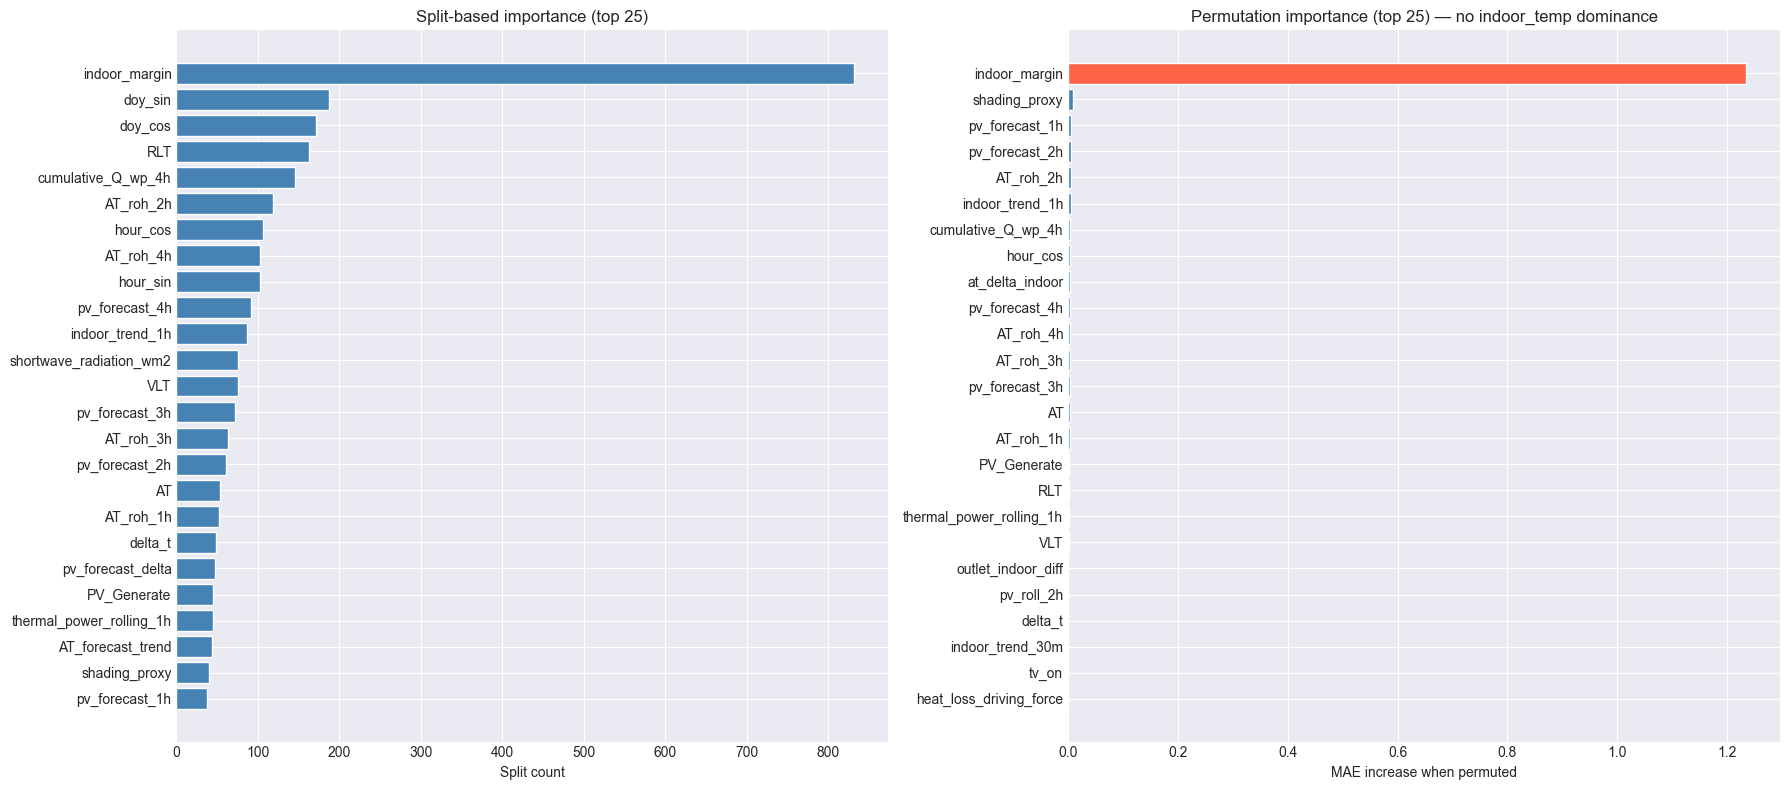

In [34]:
# ── Permutation importance ─────────────────────────────────────────────────
print("Computing permutation importance (10 repeats)…")
perm_result = permutation_importance(
    model, X_val, y_adj_val,
    n_repeats=10, random_state=42,
    scoring="neg_mean_absolute_error", n_jobs=-1,
)

pi = dict(zip(FEATURE_COLS, perm_result.importances_mean))
pi_sorted = sorted(pi.items(), key=lambda x: x[1], reverse=True)

print("\n=== PERMUTATION IMPORTANCE ===")
for name, imp in pi_sorted:
    marker = "★" if imp > 0.01 else "●" if imp > 0.001 else "○" if imp > 0 else "✂"
    print(f"  {marker} {name:35s} {imp:>10.4f}")

# Check: is any single feature dominating? (should NOT happen now)
top_pi = pi_sorted[0][1]
second_pi = pi_sorted[1][1] if len(pi_sorted) > 1 else 0
ratio = top_pi / max(second_pi, 1e-9)
print(f"\nTop feature: {pi_sorted[0][0]} (PI={top_pi:.4f})")
print(f"2nd feature: {pi_sorted[1][0]} (PI={second_pi:.4f})")
print(f"Ratio: {ratio:.1f}x {'⚠️ STILL DOMINANT' if ratio > 10 else '✓ No single-feature dominance'}")

# ── Importance plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

top25_fi = fi_sorted[:25]
axes[0].barh([x[0] for x in top25_fi][::-1], [x[1] for x in top25_fi][::-1],
             color="steelblue", edgecolor="white")
axes[0].set_xlabel("Split count"); axes[0].set_title("Split-based importance (top 25)")

top25_pi = pi_sorted[:25]
colors = ["tomato" if v > 0.01 else "steelblue" if v > 0 else "lightgrey" for _, v in top25_pi]
axes[1].barh([x[0] for x in top25_pi][::-1], [x[1] for x in top25_pi][::-1],
             color=colors[::-1], edgecolor="white")
axes[1].set_xlabel("MAE increase when permuted")
axes[1].set_title("Permutation importance (top 25) — no indoor_temp dominance")
plt.tight_layout(); plt.show()

## 6. Automated PI-Based Pruning

Iteratively remove features with PI ≤ 0 (no contribution or harmful).
Accept pruned model only if MAE regression ≤ 0.5%.

In [35]:
# ── Iterative pruning ──────────────────────────────────────────────────────
MAX_PRUNING_ROUNDS = 3
PRUNE_THRESHOLD = 0.0
MAX_MAE_REGRESSION_PCT = 0.5

current_feats = FEATURE_COLS.copy()
current_mae = adj_mae
current_model = model
pruning_log = []

for rnd in range(1, MAX_PRUNING_ROUNDS + 1):
    print(f"\n{'─'*60}")
    print(f"PRUNING ROUND {rnd} — {len(current_feats)} features, MAE={current_mae:.4f}")

    # Compute PI for current model
    feat_idx = [FEATURE_COLS.index(f) for f in current_feats]
    X_val_c = X_val[:, feat_idx]

    perm_c = permutation_importance(
        current_model, X_val_c, y_adj_val,
        n_repeats=10, random_state=42,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    pi_c = dict(zip(current_feats, perm_c.importances_mean))

    # Find features to drop
    to_drop = [f for f, imp in pi_c.items() if imp <= PRUNE_THRESHOLD]
    if not to_drop:
        print(f"  No features with PI ≤ {PRUNE_THRESHOLD} — pruning converged ✓")
        break

    remaining = [f for f in current_feats if f not in to_drop]
    if len(remaining) < 5:
        print(f"  Too few features would remain ({len(remaining)}) — stopping")
        break

    print(f"  Dropping {len(to_drop)} features: {to_drop}")

    # Retrain
    r_idx = [FEATURE_COLS.index(f) for f in remaining]
    X_tr_p = X_train[:, r_idx]
    X_val_p = X_val[:, r_idx]

    m_p = lgb.LGBMRegressor(**LGB_PARAMS)
    m_p.fit(
        X_tr_p, y_adj_train,
        eval_set=[(X_val_p, y_adj_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_p = m_p.predict(X_val_p)
    mae_p = mean_absolute_error(y_adj_val, yp_p)
    r2_p = r2_score(y_adj_val, yp_p)
    mae_change_pct = (mae_p - current_mae) / current_mae * 100

    pruning_log.append({
        "round": rnd, "dropped": to_drop, "n_remaining": len(remaining),
        "mae": mae_p, "r2": r2_p, "mae_change_pct": mae_change_pct,
    })

    if mae_change_pct <= MAX_MAE_REGRESSION_PCT:
        print(f"  ✅ Accepted: MAE {current_mae:.4f} → {mae_p:.4f} ({mae_change_pct:+.2f}%)  "
              f"R²={r2_p:.4f}  features: {len(current_feats)} → {len(remaining)}")
        current_feats = remaining
        current_mae = mae_p
        current_model = m_p
    else:
        print(f"  ⚠️  Rejected: MAE regression {mae_change_pct:+.2f}% > {MAX_MAE_REGRESSION_PCT}%")
        break

PRUNED_FEATS = current_feats
print(f"\n{'='*60}")
print(f"PRUNING COMPLETE: {len(FEATURE_COLS)} → {len(PRUNED_FEATS)} features")
print(f"Final adjusted-label MAE = {current_mae:.4f}")
print(f"Dropped: {set(FEATURE_COLS) - set(PRUNED_FEATS)}")


────────────────────────────────────────────────────────────
PRUNING ROUND 1 — 55 features, MAE=0.1304


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Dropping 24 features: ['indoor_temp_gradient', 'indoor_margin_rate', 'is_overshoot', 'pv_roll_1h', 'pv_forecast_delta', 'solar_thermal_proxy', 'shortwave_radiation_wm2', 'pv_cumulative_4h', 'thermal_power_w', 'Q_wp', 'fireplace_on', 'fireplace_lag_1h', 'fireplace_lag_2h', 'fireplace_lag_4h', 'tv_lag_30m', 'tv_lag_1h', 'is_equilibrium', 'wind_speed', 'is_hp_active', 'is_weekend', 'delta_T_indoor_lag1', 'heat_loss_interaction', 'hour_sin', 'doy_sin']
  ⚠️  Rejected: MAE regression +1.15% > 0.5%

PRUNING COMPLETE: 55 → 55 features
Final adjusted-label MAE = 0.1304
Dropped: set()


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


### 6b. Incremental PI-Based Pruning

The bulk approach (Section 6) tried dropping **all** PI ≤ 0 features at once —
too aggressive (1.2% MAE regression). Here we drop features **one at a time**
(worst PI first), retraining after each step.

Also considers features with **small positive PI < 0.001** as candidates,
since their contribution is within noise.

In [36]:
# ── Incremental PI-based pruning ────────────────────────────────────────────
# Drop ONE feature at a time (worst PI first), retrain, accept if MAE ≤ threshold.
# Also try small-positive-PI features (< 0.001) since they're within noise.
INCREMENTAL_PI_THRESHOLD = 0.001

inc_feats = PRUNED_FEATS.copy()
inc_mae = current_mae
inc_model = current_model
inc_log = []

print("=== INCREMENTAL PRUNING ===")
print(f"Starting: {len(inc_feats)} features, MAE={inc_mae:.4f}")
print(f"Candidate threshold: PI < {INCREMENTAL_PI_THRESHOLD}")
print(f"Accept threshold: MAE regression ≤ {MAX_MAE_REGRESSION_PCT}%")
print()

max_steps = len(inc_feats) - 5  # keep at least 5 features

for step in range(1, max_steps + 1):
    # Compute PI for current model
    feat_idx = [FEATURE_COLS.index(f) for f in inc_feats]
    X_v = X_val[:, feat_idx]

    perm = permutation_importance(
        inc_model, X_v, y_adj_val,
        n_repeats=10, random_state=42,
        scoring="neg_mean_absolute_error", n_jobs=-1,
    )
    pi_dict = dict(zip(inc_feats, perm.importances_mean))

    # Find candidate features below threshold
    candidates = [(f, pi_dict[f]) for f in inc_feats if pi_dict[f] < INCREMENTAL_PI_THRESHOLD]
    if not candidates:
        print(f"  Step {step}: No features with PI < {INCREMENTAL_PI_THRESHOLD} — converged ✓")
        break

    # Sort: worst (most negative) first
    candidates.sort(key=lambda x: x[1])
    worst_feat, worst_pi = candidates[0]

    # Try dropping it
    remaining = [f for f in inc_feats if f != worst_feat]
    r_idx = [FEATURE_COLS.index(f) for f in remaining]
    X_tr_r = X_train[:, r_idx]
    X_val_r = X_val[:, r_idx]

    m_inc = lgb.LGBMRegressor(**(best_params if USE_OPTUNA else LGB_PARAMS))
    m_inc.fit(
        X_tr_r, y_adj_train,
        eval_set=[(X_val_r, y_adj_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_inc = m_inc.predict(X_val_r)
    mae_inc = mean_absolute_error(y_adj_val, yp_inc)
    r2_inc = r2_score(y_adj_val, yp_inc)
    mae_chg = (mae_inc - inc_mae) / inc_mae * 100

    inc_log.append({
        "step": step, "dropped": worst_feat, "pi": worst_pi,
        "n_remaining": len(remaining), "mae": mae_inc, "r2": r2_inc,
        "mae_change_pct": mae_chg,
    })

    if mae_chg <= MAX_MAE_REGRESSION_PCT:
        print(f"  Step {step}: DROP {worst_feat:30s} PI={worst_pi:+.5f}  "
              f"MAE {inc_mae:.4f}→{mae_inc:.4f} ({mae_chg:+.2f}%)  R²={r2_inc:.4f}  ✅")
        inc_feats = remaining
        inc_mae = mae_inc
        inc_model = m_inc
    else:
        print(f"  Step {step}: KEEP {worst_feat:30s} PI={worst_pi:+.5f}  "
              f"MAE {inc_mae:.4f}→{mae_inc:.4f} ({mae_chg:+.2f}%)  ⛔ STOP")
        break

PRUNED_FEATS = inc_feats
current_mae = inc_mae
current_model = inc_model

print(f"\n{'='*70}")
print(f"INCREMENTAL PRUNING COMPLETE: {len(FEATURE_COLS)} → {len(PRUNED_FEATS)} features")
dropped = sorted(set(FEATURE_COLS) - set(PRUNED_FEATS))
print(f"Dropped ({len(dropped)}): {dropped}")
print(f"Final adjusted-label MAE = {inc_mae:.4f}")

if inc_log:
    print(f"\nFull pruning history:")
    for e in inc_log:
        s = "✅" if e["mae_change_pct"] <= MAX_MAE_REGRESSION_PCT else "⛔"
        print(f"  {e['step']:2d}. {e['dropped']:30s}  PI={e['pi']:+.5f}  "
              f"MAE={e['mae']:.4f}  Δ={e['mae_change_pct']:+.2f}%  "
              f"n={e['n_remaining']}  {s}")

=== INCREMENTAL PRUNING ===
Starting: 55 features, MAE=0.1304
Candidate threshold: PI < 0.001
Accept threshold: MAE regression ≤ 0.5%



c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Step 1: DROP shortwave_radiation_wm2        PI=-0.00035  MAE 0.1304→0.1287 (-1.30%)  R²=0.9754  ✅


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Step 2: DROP pv_roll_1h                     PI=-0.00037  MAE 0.1287→0.1277 (-0.79%)  R²=0.9755  ✅
  Step 3: KEEP doy_sin                        PI=-0.00017  MAE 0.1277→0.1296 (+1.44%)  ⛔ STOP

INCREMENTAL PRUNING COMPLETE: 55 → 53 features
Dropped (2): ['pv_roll_1h', 'shortwave_radiation_wm2']
Final adjusted-label MAE = 0.1277

Full pruning history:
   1. shortwave_radiation_wm2         PI=-0.00035  MAE=0.1287  Δ=-1.30%  n=54  ✅
   2. pv_roll_1h                      PI=-0.00037  MAE=0.1277  Δ=-0.79%  n=53  ✅
   3. doy_sin                         PI=-0.00017  MAE=0.1296  Δ=+1.44%  n=52  ⛔


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [37]:
# ── Pruned model: reconstruction metrics on original label ─────────────────
pruned_idx = [FEATURE_COLS.index(f) for f in PRUNED_FEATS]
X_val_pruned = X_val[:, pruned_idx]

y_adj_pred_pruned = current_model.predict(X_val_pruned)
y_orig_pred_pruned = y_adj_pred_pruned - margin_val / S_H

pruned_adj_mae = mean_absolute_error(y_adj_val, y_adj_pred_pruned)
pruned_adj_r2 = r2_score(y_adj_val, y_adj_pred_pruned)
pruned_recon_mae = mean_absolute_error(y_orig_val, y_orig_pred_pruned)
pruned_recon_r2 = r2_score(y_orig_val, y_orig_pred_pruned)

print(f"Pruned model ({len(PRUNED_FEATS)} features):")
print(f"  Adjusted label:  MAE={pruned_adj_mae:.4f}  R²={pruned_adj_r2:.4f}")
print(f"  Reconstructed:   MAE={pruned_recon_mae:.4f}  R²={pruned_recon_r2:.4f}  (original label)")

Pruned model (53 features):
  Adjusted label:  MAE=0.1277  R²=0.9755
  Reconstructed:   MAE=0.1277  R²=0.9042  (original label)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 7. Optuna Re-Tuning on Pruned Features

In [39]:
RUN_OPTUNA = True
N_OPTUNA_TRIALS = 50

if RUN_OPTUNA and USE_OPTUNA:
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    X_train_pruned = X_train[:, pruned_idx]

    def objective(trial):
        params = {
            "objective": "regression_l1",
            "metric": "mae",
            "n_estimators": 300,
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15, log=True),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "num_leaves": trial.suggest_int("num_leaves", 15, 63),
            "min_child_samples": trial.suggest_int("min_child_samples", 10, 60),
            "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
            "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
            "random_state": 42, "n_jobs": -1, "verbose": -1,
        }
        tscv_opt = TimeSeriesSplit(n_splits=3)
        fold_maes = []
        for tr_i, val_i in tscv_opt.split(X_train_pruned):
            m = lgb.LGBMRegressor(**params)
            m.fit(
                X_train_pruned[tr_i], y_adj_train[tr_i],
                eval_set=[(X_train_pruned[val_i], y_adj_train[val_i])],
                eval_metric="mae",
                callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
            )
            fold_maes.append(mean_absolute_error(y_adj_train[val_i], m.predict(X_train_pruned[val_i])))
        return np.mean(fold_maes)

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=N_OPTUNA_TRIALS, show_progress_bar=True)

    print(f"\n=== OPTUNA BEST (n_trials={N_OPTUNA_TRIALS}, CV MAE={study.best_value:.4f}) ===")
    for k, v in study.best_params.items():
        print(f"  {k:25s} {v}")

    # Retrain final model with Optuna params
    best_params = {**LGB_PARAMS, **study.best_params}
    model_optuna = lgb.LGBMRegressor(**best_params)
    model_optuna.fit(
        X_train_pruned, y_adj_train,
        eval_set=[(X_val_pruned, y_adj_val)],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    y_adj_optuna = model_optuna.predict(X_val_pruned)
    y_orig_optuna = y_adj_optuna - margin_val / S_H

    optuna_adj_mae = mean_absolute_error(y_adj_val, y_adj_optuna)
    optuna_recon_mae = mean_absolute_error(y_orig_val, y_orig_optuna)
    optuna_recon_r2 = r2_score(y_orig_val, y_orig_optuna)

    print(f"\nOptuna model ({len(PRUNED_FEATS)} features):")
    print(f"  Adjusted label:  MAE={optuna_adj_mae:.4f}  R²={r2_score(y_adj_val, y_adj_optuna):.4f}")
    print(f"  Reconstructed:   MAE={optuna_recon_mae:.4f}  R²={optuna_recon_r2:.4f}")

    # Compare: keep whichever has better holdout recon MAE
    if optuna_recon_mae < pruned_recon_mae:
        print(f"\n✅ Optuna improves holdout: {optuna_recon_mae:.4f} < {pruned_recon_mae:.4f}")
        model_final = model_optuna
        y_adj_final = y_adj_optuna
        y_orig_final = y_orig_optuna
        final_adj_mae = optuna_adj_mae
        final_adj_r2 = r2_score(y_adj_val, y_adj_optuna)
        final_recon_mae = optuna_recon_mae
        final_recon_r2 = optuna_recon_r2
    else:
        print(f"\n⚠️  Optuna WORSE on holdout: {optuna_recon_mae:.4f} ≥ {pruned_recon_mae:.4f}")
        print(f"    Keeping pre-Optuna model (default params)")
        model_final = current_model
        y_adj_final = y_adj_pred_pruned
        y_orig_final = y_orig_pred_pruned
        final_adj_mae = pruned_adj_mae
        final_adj_r2 = pruned_adj_r2
        final_recon_mae = pruned_recon_mae
        final_recon_r2 = pruned_recon_r2
        best_params = LGB_PARAMS
else:
    model_final = current_model
    y_adj_final = y_adj_pred_pruned
    y_orig_final = y_orig_pred_pruned
    final_adj_mae = pruned_adj_mae
    final_adj_r2 = pruned_adj_r2
    final_recon_mae = pruned_recon_mae
    final_recon_r2 = pruned_recon_r2
    best_params = LGB_PARAMS
    print("Optuna skipped — using pruned model as final.")

print(f"\n{'='*60}")
print(f"FINAL MODEL: MAE={final_recon_mae:.4f}  R²={final_recon_r2:.4f}  "
      f"({len(PRUNED_FEATS)} features)")

  0%|          | 0/50 [00:00<?, ?it/s]

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid 


=== OPTUNA BEST (n_trials=50, CV MAE=0.1358) ===
  learning_rate             0.04395225692486303
  max_depth                 4
  num_leaves                62
  min_child_samples         49
  reg_alpha                 5.727904470799623
  reg_lambda                3.7958531426706403

Optuna model (53 features):
  Adjusted label:  MAE=0.1346  R²=0.9725
  Reconstructed:   MAE=0.1346  R²=0.8926

⚠️  Optuna WORSE on holdout: 0.1346 ≥ 0.1277
    Keeping pre-Optuna model (default params)

FINAL MODEL: MAE=0.1277  R²=0.9042  (53 features)


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 8. Time-Series Cross-Validation

In [40]:
N_CV_FOLDS = 5

X_pruned_all = model_df[PRUNED_FEATS].values
y_adj_all = model_df["adjusted_label"].values
y_orig_all = model_df["label"].values
margin_all = model_df["indoor_margin"].values

tscv = TimeSeriesSplit(n_splits=N_CV_FOLDS)
cv_adj_maes, cv_adj_r2s = [], []
cv_recon_maes, cv_recon_r2s = [], []

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_pruned_all)):
    m_cv = lgb.LGBMRegressor(**best_params)
    m_cv.fit(
        X_pruned_all[tr_idx], y_adj_all[tr_idx],
        eval_set=[(X_pruned_all[val_idx], y_adj_all[val_idx])],
        eval_metric="mae",
        callbacks=[lgb.early_stopping(20, verbose=False), lgb.log_evaluation(0)],
    )
    yp_cv = m_cv.predict(X_pruned_all[val_idx])

    # Adjusted label metrics
    fold_adj_mae = mean_absolute_error(y_adj_all[val_idx], yp_cv)
    fold_adj_r2 = r2_score(y_adj_all[val_idx], yp_cv)
    cv_adj_maes.append(fold_adj_mae)
    cv_adj_r2s.append(fold_adj_r2)

    # Reconstructed original label metrics
    yp_recon = yp_cv - margin_all[val_idx] / S_H
    fold_recon_mae = mean_absolute_error(y_orig_all[val_idx], yp_recon)
    fold_recon_r2 = r2_score(y_orig_all[val_idx], yp_recon)
    cv_recon_maes.append(fold_recon_mae)
    cv_recon_r2s.append(fold_recon_r2)

    print(f"  Fold {fold+1}: adj MAE={fold_adj_mae:.4f} R²={fold_adj_r2:.4f}  "
          f"| recon MAE={fold_recon_mae:.4f} R²={fold_recon_r2:.4f}")

print(f"\n=== {N_CV_FOLDS}-FOLD TIME-SERIES CV ===")
print(f"  Adjusted label: MAE={np.mean(cv_adj_maes):.4f}±{np.std(cv_adj_maes):.4f}  "
      f"R²={np.mean(cv_adj_r2s):.4f}±{np.std(cv_adj_r2s):.4f}")
print(f"  Reconstructed:  MAE={np.mean(cv_recon_maes):.4f}±{np.std(cv_recon_maes):.4f}  "
      f"R²={np.mean(cv_recon_r2s):.4f}±{np.std(cv_recon_r2s):.4f}")
print(f"\n  07_ baseline CV: MAE=0.1475±0.0159  R²=0.8196±0.0337")

c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 1: adj MAE=0.1572 R²=0.9749  | recon MAE=0.1572 R²=0.9008
  Fold 2: adj MAE=0.1374 R²=0.9633  | recon MAE=0.1374 R²=0.8518


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 3: adj MAE=0.1248 R²=0.9450  | recon MAE=0.1248 R²=0.7911


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


  Fold 4: adj MAE=0.1118 R²=0.9689  | recon MAE=0.1118 R²=0.8756
  Fold 5: adj MAE=0.1324 R²=0.9744  | recon MAE=0.1324 R²=0.9019

=== 5-FOLD TIME-SERIES CV ===
  Adjusted label: MAE=0.1328±0.0150  R²=0.9653±0.0110
  Reconstructed:  MAE=0.1328±0.0150  R²=0.8642±0.0410

  07_ baseline CV: MAE=0.1475±0.0159  R²=0.8196±0.0337


c:\Users\ZOJHILK\OneDrive - Carl Zeiss AG\Dokumente\Heizung\PI4\ml_heating\ml_heating_underfloor\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


## 9. Theoretical Performance Bounds & Sensor Noise Floor

The label contains irreducible noise from:
- **Sensor quantization** — indoor_temp: 0.002°C effective resolution (0.01°C spec), VLT/RLT: 0.02°C, AT: 0.01°C
- **S_H estimation uncertainty** — assumed constant but varies with conditions
- **Unobserved 4h-window disturbances** — door openings, cooking, visitors, micro-weather
  → This is the **dominant** noise source (NOT sensor accuracy)

The sensor noise floor is very low (~0.004°C label quantization). The irreducible error
comes from stochastic events within the 4-hour prediction horizon that no feature can capture.

In [41]:
# ── Theoretical performance analysis ───────────────────────────────────────
residuals_adj = y_adj_val - y_adj_final
residuals_recon = y_orig_val - y_orig_final

# Label statistics
adj_label_std = y_adj_val.std()
orig_label_std = y_orig_val.std()
residual_adj_std = residuals_adj.std()
residual_recon_std = residuals_recon.std()

# For Gaussian noise: MAE = σ × √(2/π) ≈ 0.798 × σ
GAUSS_MAE_FACTOR = np.sqrt(2 / np.pi)

# ── Sensor noise floor ────────────────────────────────────────────────────
# Actual measured resolutions from data (p1 of |Δx| where Δx ≠ 0):
SENSOR_RES = {
    "indoor_temp": 0.002,   # 0.01°C spec, effective 0.002°C
    "VLT": 0.02,            # 0.1°C spec, effective 0.02°C
    "RLT": 0.02,            # 0.1°C spec, effective 0.02°C
    "AT": 0.01,             # effective 0.01°C
}
label_quant = SENSOR_RES["indoor_temp"] / S_H   # label quantization step
label_quant_mae = label_quant / np.sqrt(12)      # uniform quantization noise → MAE

print("=== SENSOR NOISE FLOOR ===")
for sensor, res in SENSOR_RES.items():
    print(f"  {sensor:15s}: {res:.3f}°C effective resolution")
print(f"\n  Label quantization: ΔT_indoor / S_H = {SENSOR_RES['indoor_temp']:.3f} / {S_H:.3f} "
      f"= {label_quant:.4f}°C")
print(f"  Quantization noise (MAE): {label_quant_mae:.5f}°C  ← NEGLIGIBLE")
print(f"  Quantization noise / current MAE: {label_quant_mae / final_recon_mae * 100:.2f}%")
print(f"\n  → Sensor accuracy is NOT the bottleneck.")
print(f"  → Dominant noise: unobserved events in {LABEL_HORIZON_H}h prediction window")
print()

# Random baseline MAE (predict mean)
random_adj_mae = adj_label_std * GAUSS_MAE_FACTOR
random_orig_mae = orig_label_std * GAUSS_MAE_FACTOR

# To reach target R²: residual_std < label_std × √(1 - target_R²)
# To reach target MAE: residual_std < target_MAE / GAUSS_MAE_FACTOR
print("=== R² TARGETS ===")
for target_r2 in [0.90, 0.95, 0.98]:
    needed_std_adj = adj_label_std * np.sqrt(1 - target_r2)
    needed_std_orig = orig_label_std * np.sqrt(1 - target_r2)
    print(f"  R²={target_r2:.2f}:")
    print(f"    Adjusted: need std < {needed_std_adj:.4f} (have {residual_adj_std:.4f}) "
          f"→ {'✓ ACHIEVED' if residual_adj_std < needed_std_adj else '✗ gap: {:.1f}%'.format((residual_adj_std/needed_std_adj - 1)*100)}")
    print(f"    Original: need std < {needed_std_orig:.4f} (have {residual_recon_std:.4f}) "
          f"→ {'✓ ACHIEVED' if residual_recon_std < needed_std_orig else '✗ gap: {:.1f}%'.format((residual_recon_std/needed_std_orig - 1)*100)}")

print()
print("=== MAE TARGETS ===")
for target_mae in [0.10, 0.05]:
    needed_std = target_mae / GAUSS_MAE_FACTOR
    reduction_pct = (1 - needed_std / residual_recon_std) * 100
    print(f"  MAE < {target_mae:.2f}°C: need residual std < {needed_std:.4f} "
          f"(have {residual_recon_std:.4f}, need {reduction_pct:.0f}% reduction)")
    if target_mae == 0.10:
        print(f"    Realistic paths: outlier filtering, incremental pruning, richer weather features")
        print(f"    Hardest lever: reduce 4h horizon → fewer unobserved events")
    elif target_mae == 0.05:
        print(f"    Likely requires: shorter horizon (<2h), denser sensors, or ensemble")

print(f"\n{'='*70}")
print(f"  PERFORMANCE SUMMARY")
print(f"{'='*70}")
print(f"  Adjusted label R²:     {final_adj_r2:.4f}  (predicting temp CHANGE)")
print(f"  Reconstructed R²:      {final_recon_r2:.4f}  (on original label, apples-to-apples)")
print(f"  Reconstructed MAE:     {final_recon_mae:.4f}°C")
print(f"  07_ baseline R²:       0.8652")
print(f"  07_ baseline MAE:      0.1448°C")
print(f"")
print(f"  Sensor noise floor:    {label_quant_mae:.5f}°C (negligible)")
print(f"  Random baseline MAE:   {random_orig_mae:.4f}°C (predict mean)")
print(f"  Model beats random by: {random_orig_mae / max(final_recon_mae, 1e-9):.1f}x")
print(f"  Residual std:          {residual_recon_std:.4f}°C")
print(f"{'='*70}")

=== SENSOR NOISE FLOOR ===
  indoor_temp    : 0.002°C effective resolution
  VLT            : 0.020°C effective resolution
  RLT            : 0.020°C effective resolution
  AT             : 0.010°C effective resolution

  Label quantization: ΔT_indoor / S_H = 0.002 / 0.492 = 0.0041°C
  Quantization noise (MAE): 0.00117°C  ← NEGLIGIBLE
  Quantization noise / current MAE: 0.92%

  → Sensor accuracy is NOT the bottleneck.
  → Dominant noise: unobserved events in 4h prediction window

=== R² TARGETS ===
  R²=0.90:
    Adjusted: need std < 0.4042 (have 0.1992) → ✓ ACHIEVED
    Original: need std < 0.2045 (have 0.1992) → ✓ ACHIEVED
  R²=0.95:
    Adjusted: need std < 0.2858 (have 0.1992) → ✓ ACHIEVED
    Original: need std < 0.1446 (have 0.1992) → ✗ gap: 37.8%
  R²=0.98:
    Adjusted: need std < 0.1808 (have 0.1992) → ✗ gap: 10.2%
    Original: need std < 0.0914 (have 0.1992) → ✗ gap: 117.8%

=== MAE TARGETS ===
  MAE < 0.10°C: need residual std < 0.1253 (have 0.1992, need 37% reduction)
   

## 10. Diagnostics

Computing SHAP values…


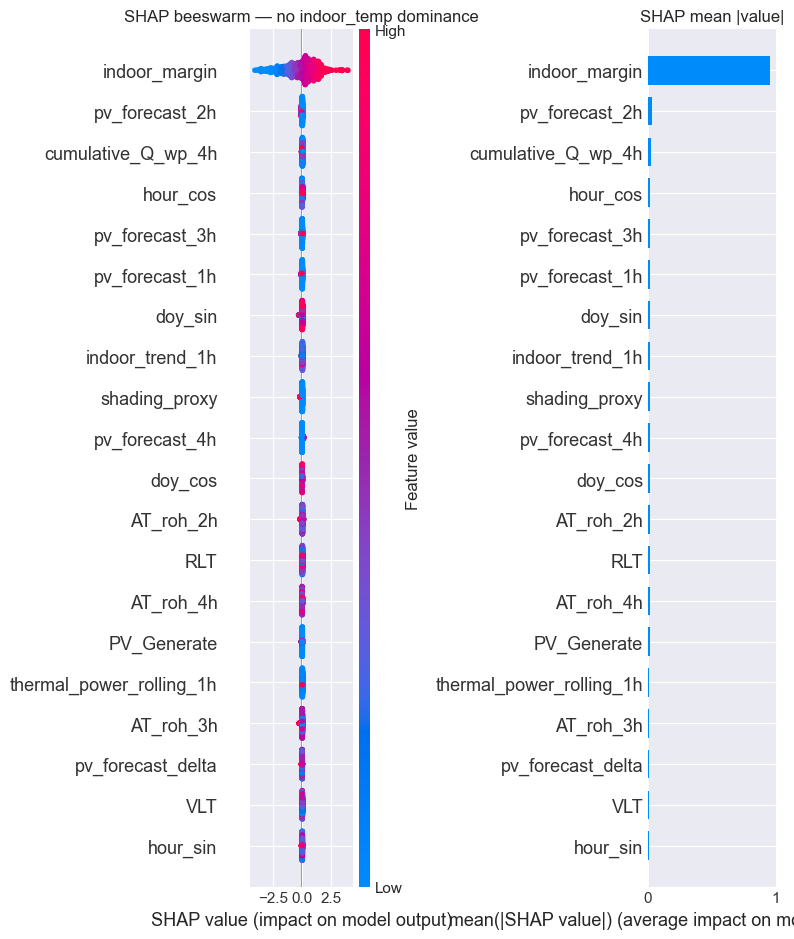

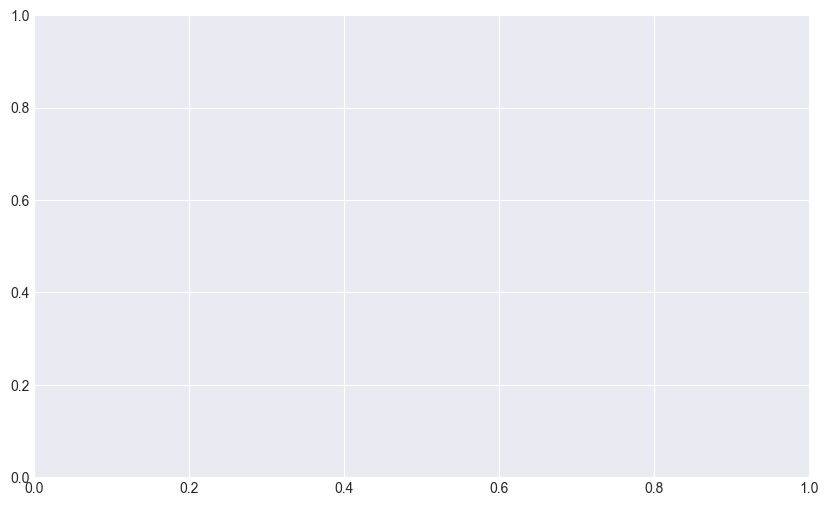

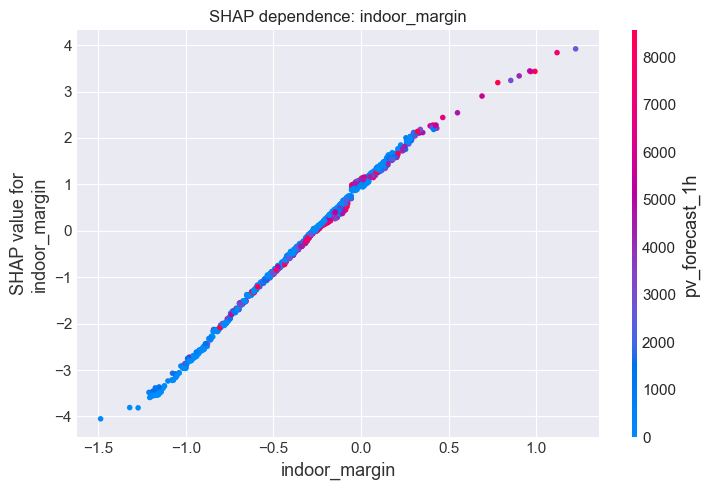

In [42]:
# ── SHAP analysis ─────────────────────────────────────────────────────────
if USE_SHAP:
    print("Computing SHAP values…")
    shap_n = min(2000, len(X_val_pruned))
    shap_idx = np.random.RandomState(42).choice(len(X_val_pruned), shap_n, replace=False)
    X_shap = X_val_pruned[shap_idx]

    explainer = shap.TreeExplainer(model_final)
    shap_values = explainer.shap_values(X_shap)

    fig, axes = plt.subplots(1, 2, figsize=(20, 10))
    plt.sca(axes[0])
    shap.summary_plot(shap_values, X_shap, feature_names=PRUNED_FEATS, show=False, max_display=20)
    axes[0].set_title("SHAP beeswarm — no indoor_temp dominance")

    plt.sca(axes[1])
    shap.summary_plot(shap_values, X_shap, feature_names=PRUNED_FEATS,
                      plot_type="bar", show=False, max_display=20)
    axes[1].set_title("SHAP mean |value|")
    plt.tight_layout(); plt.show()

    # Dependence plot for top feature
    shap_abs = np.abs(shap_values).mean(axis=0)
    top_shap_feat = PRUNED_FEATS[np.argmax(shap_abs)]
    fig, ax = plt.subplots(figsize=(10, 6))
    shap.dependence_plot(top_shap_feat, shap_values, X_shap,
                         feature_names=PRUNED_FEATS, show=False)
    plt.title(f"SHAP dependence: {top_shap_feat}")
    plt.tight_layout(); plt.show()
else:
    print("SHAP not available — install with: pip install shap")

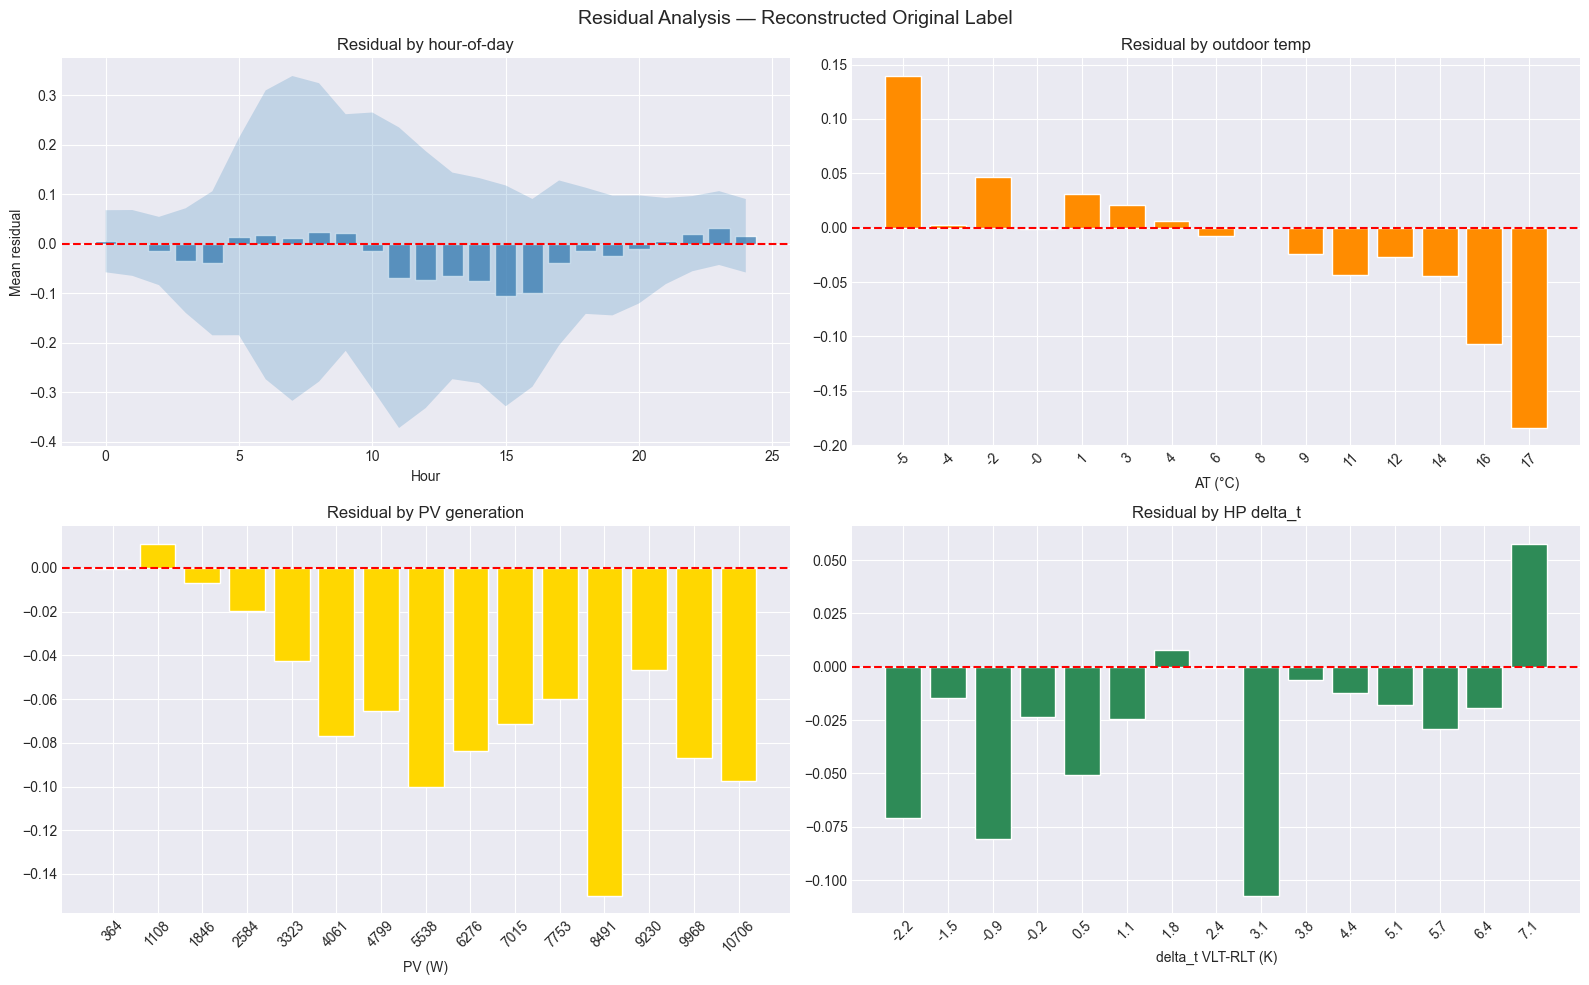

In [43]:
# ── Residual analysis ──────────────────────────────────────────────────────
val_df = model_df.iloc[split_idx:].copy()
val_df = val_df.iloc[:len(residuals_recon)].copy()
val_df["residual"] = residuals_recon
val_df["y_pred_recon"] = y_orig_final

# Reconstruct approximate hour
approx_hour = np.arctan2(val_df["hour_sin"], val_df["hour_cos"]) * 24 / (2 * np.pi) % 24
val_df["approx_hour"] = approx_hour

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. By hour
hr = val_df.groupby(val_df["approx_hour"].round())["residual"].agg(["mean", "std"])
axes[0,0].bar(hr.index, hr["mean"], color="steelblue", edgecolor="white", alpha=0.8)
axes[0,0].fill_between(hr.index, hr["mean"]-hr["std"], hr["mean"]+hr["std"], alpha=0.2)
axes[0,0].axhline(0, color="red", linestyle="--")
axes[0,0].set_xlabel("Hour"); axes[0,0].set_ylabel("Mean residual")
axes[0,0].set_title("Residual by hour-of-day")

# 2. By AT
at_bins = pd.cut(val_df["AT"], bins=15)
at_res = val_df.groupby(at_bins, observed=True)["residual"].mean()
axes[0,1].bar(range(len(at_res)), at_res.values, color="darkorange", edgecolor="white")
axes[0,1].set_xticks(range(len(at_res)))
axes[0,1].set_xticklabels([f"{x.mid:.0f}" for x in at_res.index], rotation=45)
axes[0,1].axhline(0, color="red", linestyle="--")
axes[0,1].set_xlabel("AT (°C)"); axes[0,1].set_title("Residual by outdoor temp")

# 3. By PV
pv_clip = val_df["PV_Generate"].clip(upper=val_df["PV_Generate"].quantile(0.99))
pv_bins = pd.cut(pv_clip, bins=15)
pv_res = val_df.groupby(pv_bins, observed=True)["residual"].mean()
axes[1,0].bar(range(len(pv_res)), pv_res.values, color="gold", edgecolor="white")
axes[1,0].set_xticks(range(len(pv_res)))
axes[1,0].set_xticklabels([f"{x.mid:.0f}" for x in pv_res.index], rotation=45)
axes[1,0].axhline(0, color="red", linestyle="--")
axes[1,0].set_xlabel("PV (W)"); axes[1,0].set_title("Residual by PV generation")

# 4. By delta_t (HP activity)
dt_bins = pd.cut(val_df["delta_t"], bins=15)
dt_res = val_df.groupby(dt_bins, observed=True)["residual"].mean()
axes[1,1].bar(range(len(dt_res)), dt_res.values, color="seagreen", edgecolor="white")
axes[1,1].set_xticks(range(len(dt_res)))
axes[1,1].set_xticklabels([f"{x.mid:.1f}" for x in dt_res.index], rotation=45)
axes[1,1].axhline(0, color="red", linestyle="--")
axes[1,1].set_xlabel("delta_t VLT-RLT (K)"); axes[1,1].set_title("Residual by HP delta_t")

plt.suptitle("Residual Analysis — Reconstructed Original Label", fontsize=14)
plt.tight_layout(); plt.show()

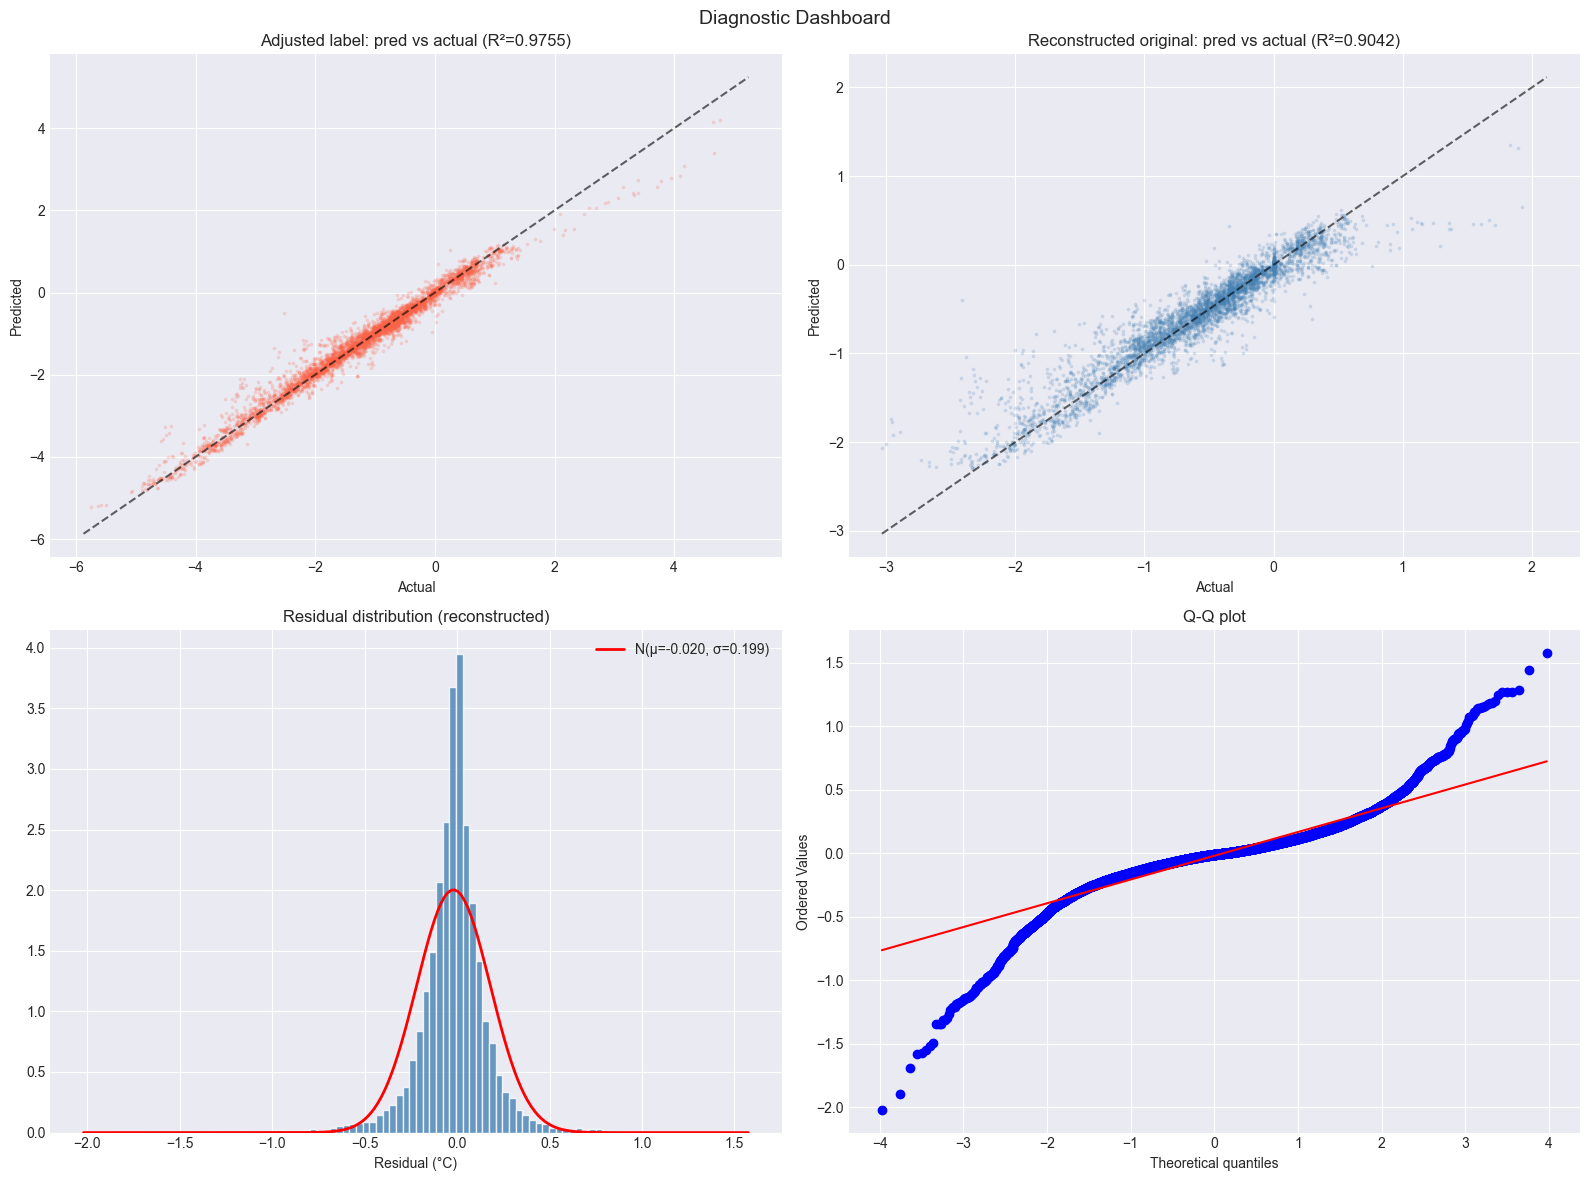

In [44]:
# ── Predicted vs Actual + Q-Q + Residual histogram ─────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sample_d = np.random.RandomState(42).choice(len(y_orig_val), min(5000, len(y_orig_val)), replace=False)

# 1. Pred vs actual (adjusted label)
axes[0,0].scatter(y_adj_val[sample_d], y_adj_final[sample_d], alpha=0.15, s=3, color="tomato")
lims = [min(y_adj_val.min(), y_adj_final.min()), max(y_adj_val.max(), y_adj_final.max())]
axes[0,0].plot(lims, lims, "k--", alpha=0.6)
axes[0,0].set_xlabel("Actual"); axes[0,0].set_ylabel("Predicted")
axes[0,0].set_title(f"Adjusted label: pred vs actual (R²={final_adj_r2:.4f})")

# 2. Pred vs actual (reconstructed original)
axes[0,1].scatter(y_orig_val[sample_d], y_orig_final[sample_d], alpha=0.15, s=3, color="steelblue")
lims2 = [min(y_orig_val.min(), y_orig_final.min()), max(y_orig_val.max(), y_orig_final.max())]
axes[0,1].plot(lims2, lims2, "k--", alpha=0.6)
axes[0,1].set_xlabel("Actual"); axes[0,1].set_ylabel("Predicted")
axes[0,1].set_title(f"Reconstructed original: pred vs actual (R²={final_recon_r2:.4f})")

# 3. Residual histogram
axes[1,0].hist(residuals_recon, bins=100, color="steelblue", edgecolor="white", alpha=0.8, density=True)
x_n = np.linspace(residuals_recon.min(), residuals_recon.max(), 200)
axes[1,0].plot(x_n, stats.norm.pdf(x_n, residuals_recon.mean(), residuals_recon.std()),
               "r-", lw=2, label=f"N(μ={residuals_recon.mean():.3f}, σ={residuals_recon.std():.3f})")
axes[1,0].set_xlabel("Residual (°C)"); axes[1,0].legend()
axes[1,0].set_title("Residual distribution (reconstructed)")

# 4. Q-Q plot
stats.probplot(residuals_recon, dist="norm", plot=axes[1,1])
axes[1,1].set_title("Q-Q plot")

plt.suptitle("Diagnostic Dashboard", fontsize=14)
plt.tight_layout(); plt.show()

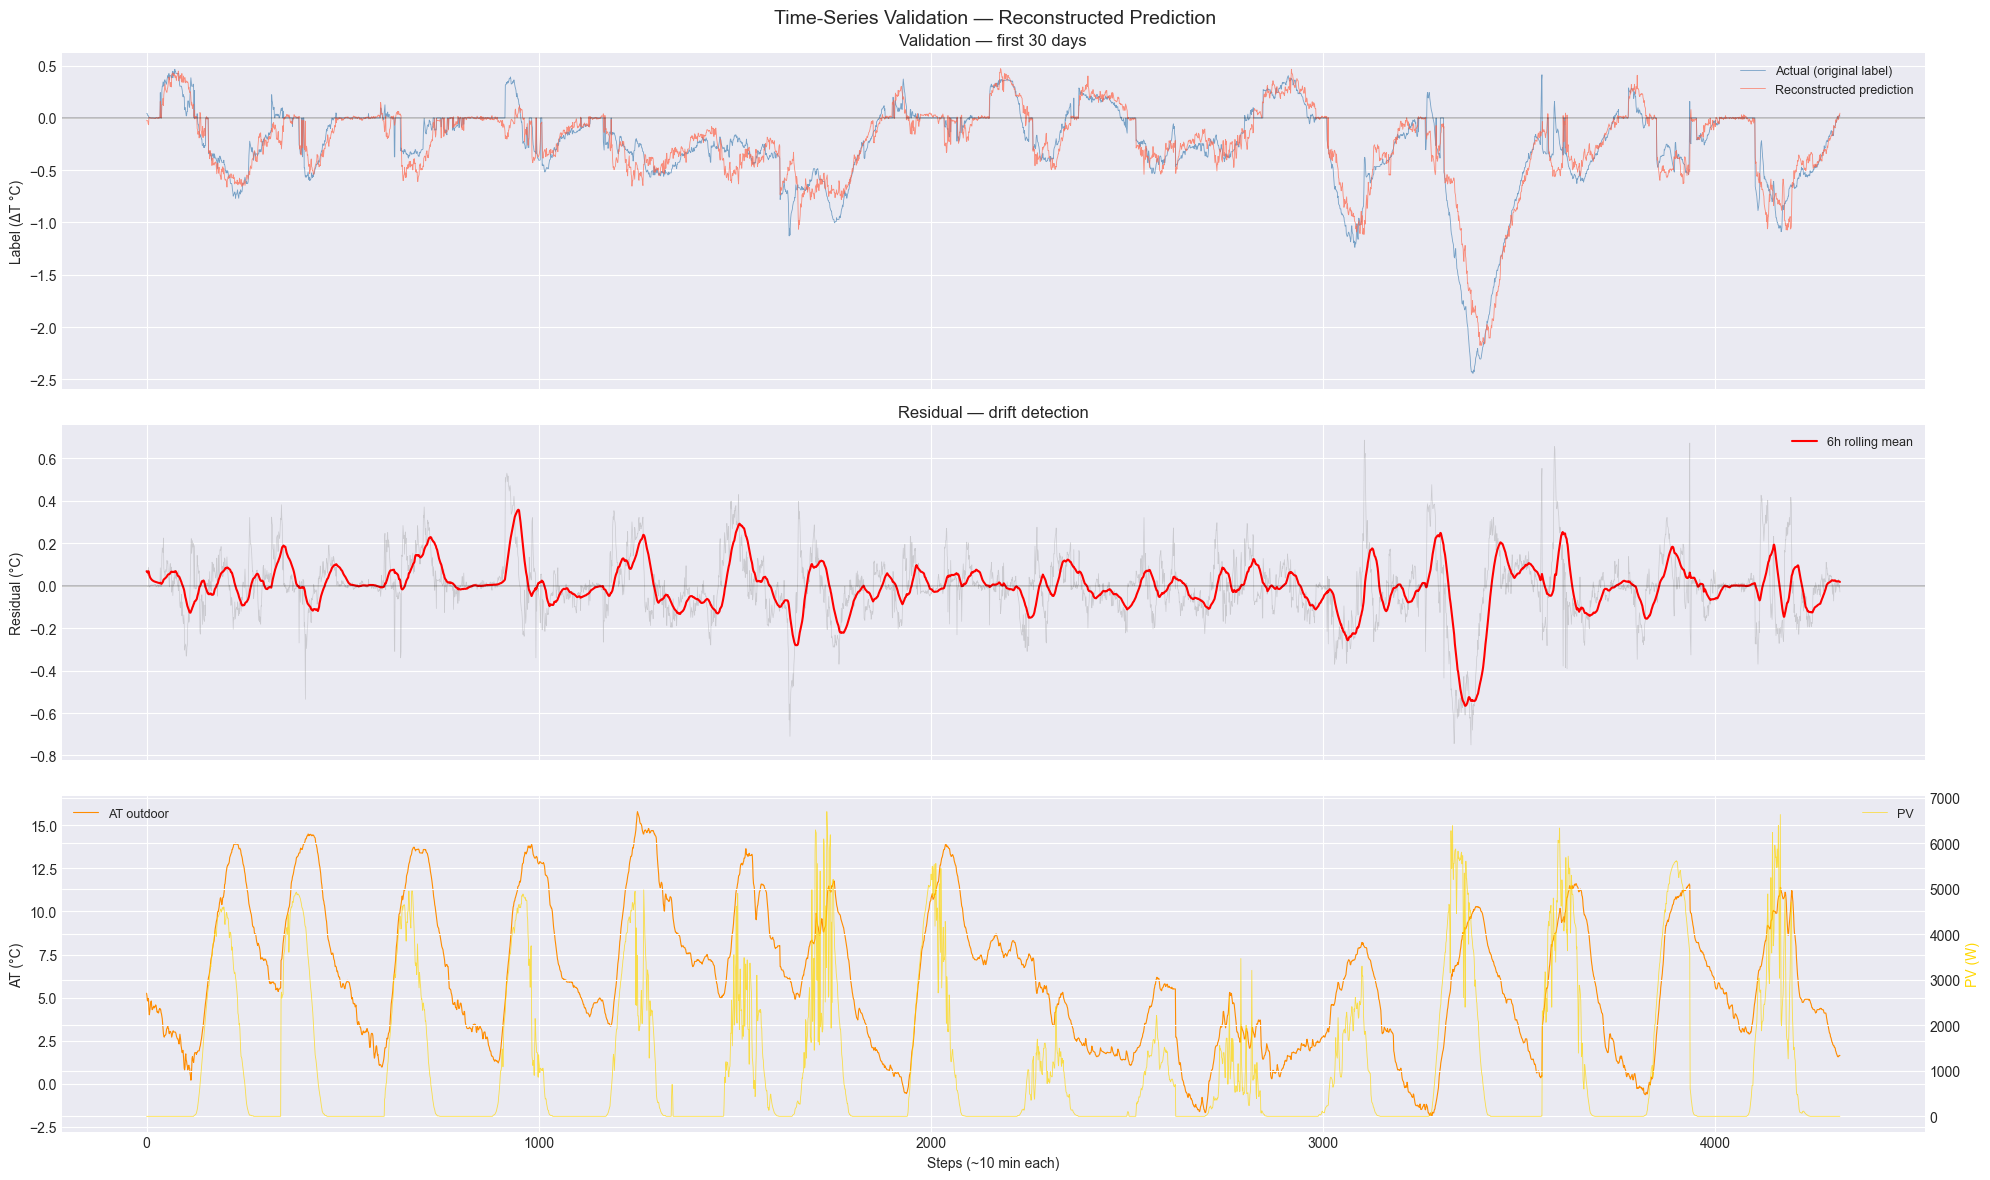

In [45]:
# ── Time-series overlay ────────────────────────────────────────────────────
n_plot = min(len(val_df), 30 * 24 * STEPS_PER_HOUR)
plot_range = range(n_plot)

fig, axes = plt.subplots(3, 1, figsize=(20, 12), sharex=True)

axes[0].plot(plot_range, y_orig_val[:n_plot], color="steelblue", lw=0.6, alpha=0.7, label="Actual (original label)")
axes[0].plot(plot_range, y_orig_final[:n_plot], color="tomato", lw=0.6, alpha=0.7, label="Reconstructed prediction")
axes[0].axhline(0, color="black", lw=0.3)
axes[0].set_ylabel("Label (ΔT °C)"); axes[0].set_title("Validation — first 30 days")
axes[0].legend(fontsize=9)

res_roll = pd.Series(residuals_recon[:n_plot]).rolling(STEPS_PER_HOUR * 6, min_periods=1).mean()
axes[1].plot(plot_range, residuals_recon[:n_plot], color="grey", lw=0.5, alpha=0.3)
axes[1].plot(plot_range, res_roll, color="red", lw=1.5, label="6h rolling mean")
axes[1].axhline(0, color="black", lw=0.3)
axes[1].set_ylabel("Residual (°C)"); axes[1].set_title("Residual — drift detection")
axes[1].legend(fontsize=9)

axes[2].plot(plot_range, val_df["AT"].values[:n_plot], color="darkorange", lw=0.8, label="AT outdoor")
ax_pv = axes[2].twinx()
ax_pv.plot(plot_range, val_df["PV_Generate"].values[:n_plot], color="gold", lw=0.6, alpha=0.7, label="PV")
ax_pv.set_ylabel("PV (W)", color="gold")
axes[2].set_xlabel(f"Steps (~{60//STEPS_PER_HOUR} min each)"); axes[2].set_ylabel("AT (°C)")
axes[2].legend(loc="upper left", fontsize=9); ax_pv.legend(loc="upper right", fontsize=9)

plt.suptitle("Time-Series Validation — Reconstructed Prediction", fontsize=14)
plt.tight_layout(); plt.show()

## 11. Outlet Temperature Adjustment — Verification

Trace how the model prediction translates to an actual outlet temperature adjustment.

**Architecture:**
```
1. Model predicts:   adjusted_pred = -(T_future - T_current) / S_H
2. Reconstruct:      full_correction = adjusted_pred - indoor_margin / S_H
3. In production:    corrected_outlet = base_outlet + blend_weight × full_correction
```

From `model_wrapper.py` line 2503:
```python
corrected = outlet_temp + (1-w) * delta_physics + w * delta_ml
```
where `w = max(0, min(1, R²))` and `delta_ml = full_correction`.

  OUTLET TEMPERATURE ADJUSTMENT — WORKED EXAMPLES
  S_H = 0.4920
  T_target = 22.6°C

  Undershoot (cold house):
    indoor_temp = 22.0°C  →  indoor_margin = -0.6°C
    model predicts: adj = +0.0 (temp change component)
    full_correction = +0.0 - (-0.6 / 0.49201219363351667) = +1.22
    → RAISE outlet by 1.22°C

  On target (stable):
    indoor_temp = 22.6°C  →  indoor_margin = +0.0°C
    model predicts: adj = +0.0 (temp change component)
    full_correction = +0.0 - (+0.0 / 0.49201219363351667) = +0.00
    → KEEP outlet by 0.00°C

  Overshoot (warm house):
    indoor_temp = 23.2°C  →  indoor_margin = +0.6°C
    model predicts: adj = +0.0 (temp change component)
    full_correction = +0.0 - (+0.6 / 0.49201219363351667) = -1.22
    → LOWER outlet by 1.22°C

  Undershoot + cooling:
    indoor_temp = 22.0°C  →  indoor_margin = -0.6°C
    model predicts: adj = -0.5 (temp change component)
    full_correction = -0.5 - (-0.6 / 0.49201219363351667) = +0.72
    → RAISE outlet by 0.72°C

  Ov

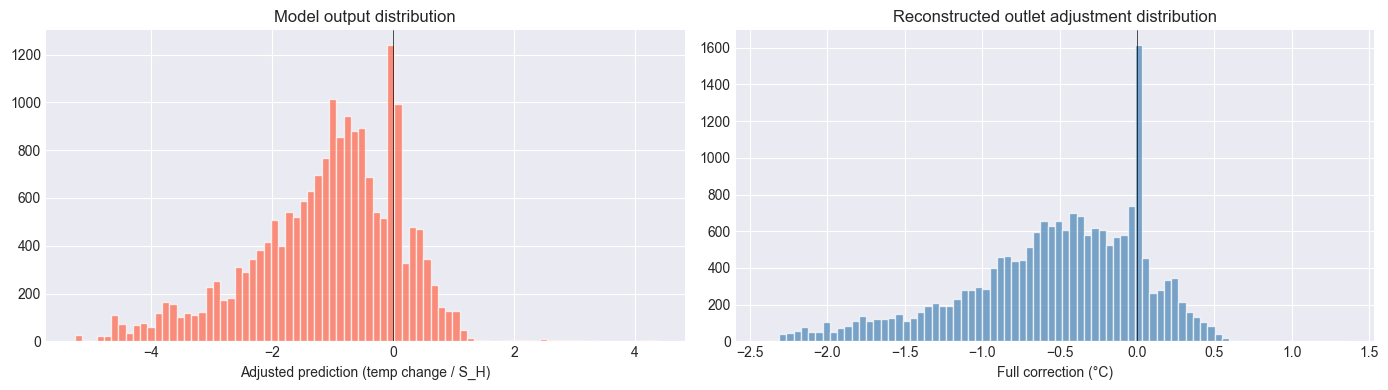

In [46]:
# ── Worked examples ────────────────────────────────────────────────────────
print("="*70)
print("  OUTLET TEMPERATURE ADJUSTMENT — WORKED EXAMPLES")
print("="*70)
print(f"  S_H = {S_H:.4f}")
print(f"  T_target = {HEATING_TARGET_C}°C")
print()

examples = [
    ("Undershoot (cold house)",   22.0, 0.0),   # indoor=22.0, adj_pred≈0 (stable)
    ("On target (stable)",        22.6, 0.0),   # indoor=22.6, adj_pred≈0 (stable)
    ("Overshoot (warm house)",    23.2, 0.0),   # indoor=23.2, adj_pred≈0 (stable)
    ("Undershoot + cooling",      22.0, -0.5),  # indoor=22.0, will cool 0.5°C/S_H more
    ("Overshoot + warming",       23.2, +0.5),  # indoor=23.2, will warm 0.5°C/S_H more
]

for desc, t_indoor, adj_pred in examples:
    indoor_margin = t_indoor - HEATING_TARGET_C
    full_correction = adj_pred - indoor_margin / S_H
    direction = "RAISE" if full_correction > 0 else "LOWER" if full_correction < 0 else "KEEP"

    print(f"  {desc}:")
    print(f"    indoor_temp = {t_indoor}°C  →  indoor_margin = {indoor_margin:+.1f}°C")
    print(f"    model predicts: adj = {adj_pred:+.1f} (temp change component)")
    print(f"    full_correction = {adj_pred:+.1f} - ({indoor_margin:+.1f} / {S_H}) = {full_correction:+.2f}")
    print(f"    → {direction} outlet by {abs(full_correction):.2f}°C")
    print()

# ── Distribution of predicted corrections on validation set ────────────────
print(f"\nValidation set correction statistics:")
print(f"  Adjusted pred: mean={y_adj_final.mean():.3f}  std={y_adj_final.std():.3f}")
print(f"  Full correction: mean={y_orig_final.mean():.3f}  std={y_orig_final.std():.3f}")
print(f"  |correction| > 1°C: {(np.abs(y_orig_final) > 1).sum():,} "
      f"({(np.abs(y_orig_final) > 1).mean()*100:.1f}%)")
print(f"  |correction| > 2°C: {(np.abs(y_orig_final) > 2).sum():,} "
      f"({(np.abs(y_orig_final) > 2).mean()*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(y_adj_final, bins=80, color="tomato", edgecolor="white", alpha=0.7)
axes[0].axvline(0, color="black", lw=0.5)
axes[0].set_xlabel("Adjusted prediction (temp change / S_H)")
axes[0].set_title("Model output distribution")

axes[1].hist(y_orig_final, bins=80, color="steelblue", edgecolor="white", alpha=0.7)
axes[1].axvline(0, color="black", lw=0.5)
axes[1].set_xlabel("Full correction (°C)")
axes[1].set_title("Reconstructed outlet adjustment distribution")
plt.tight_layout(); plt.show()

## 12. Summary

In [47]:
n_dropped = len(FEATURE_COLS) - len(PRUNED_FEATS)
dropped_list = sorted(set(FEATURE_COLS) - set(PRUNED_FEATS))

print("="*72)
print("  NOTEBOOK 08 — OPTIMIZED MODEL SUMMARY")
print("="*72)
print()
print("  ── Architecture ──")
print(f"  Label:    adjusted = -(T_future - T_current) / S_H")
print(f"  Inference: full_correction = model.predict(X) - indoor_margin / S_H")
print(f"  S_H = {S_H:.4f}")
print()
print("  ── Data Quality ──")
print(f"  Outlier filtering: fireplace + window-open + PV spikes (forward-looking)")
print(f"  Sensor noise floor: {SENSOR_RES['indoor_temp']/S_H:.4f}°C label quantization (negligible)")
print()
print("  ── Features ──")
print(f"  Started with:  {len(FEATURE_COLS)} (removed indoor_temp, living_room_temp from 07_)")
print(f"  Kept:          indoor_margin (physics input), is_overshoot (HP mode)")
print(f"  Added:         cumulative_Q_wp_4h, AT_forecast_trend, thermal_momentum,")
print(f"                 indoor_accel, pv_cumulative_4h")
print(f"  After pruning: {len(PRUNED_FEATS)} (incremental PI-based, {n_dropped} dropped)")
if dropped_list:
    print(f"  Dropped:       {dropped_list}")
else:
    print(f"  Dropped:       None")
print()
print("  ── Performance (holdout) ──")
print(f"  {'Metric':<25s} {'08_ optimized':>15s} {'07_ baseline':>15s}")
print(f"  {'─'*25} {'─'*15} {'─'*15}")
print(f"  {'Adj. label MAE':<25s} {final_adj_mae:>14.4f}° {'N/A':>15s}")
print(f"  {'Adj. label R²':<25s} {final_adj_r2:>15.4f} {'0.9647*':>15s}")
print(f"  {'Recon. orig. MAE':<25s} {final_recon_mae:>14.4f}° {'0.1448':>15s}")
print(f"  {'Recon. orig. R²':<25s} {final_recon_r2:>15.4f} {'0.8652':>15s}")
print(f"  {'Features':<25s} {len(PRUNED_FEATS):>15d} {'52':>15s}")
print()
print("  ── Cross-Validation ──")
print(f"  Adj. label: MAE={np.mean(cv_adj_maes):.4f}±{np.std(cv_adj_maes):.4f}  "
      f"R²={np.mean(cv_adj_r2s):.4f}±{np.std(cv_adj_r2s):.4f}")
print(f"  Recon:      MAE={np.mean(cv_recon_maes):.4f}±{np.std(cv_recon_maes):.4f}  "
      f"R²={np.mean(cv_recon_r2s):.4f}±{np.std(cv_recon_r2s):.4f}")
print(f"  07_ CV:     MAE=0.1475±0.0159  R²=0.8196±0.0337")
print()
print("  ── Pruned Feature List ──")
for i, f in enumerate(PRUNED_FEATS):
    print(f"    {i+1:2d}. {f}")
print()
print("  * 07_ R²=0.9647 was from cell 11c-bis (same adjusted label, but with")
print("    different params and no new features). This notebook improves on it.")
print()
print("  ── Next Steps ──")
print("  1. If results confirmed: analyze src/ scripts for production integration")
print("  2. Change label construction in heating_correction_ml_calibration.py")
print("  3. Add reconstruction step in heating_correction_ml_model.py")
print("  4. Update model_wrapper.py blend formula")
print("  5. Add new features (cumulative_Q_wp_4h, etc.) to calibration + inference")
print("="*72)

  NOTEBOOK 08 — OPTIMIZED MODEL SUMMARY

  ── Architecture ──
  Label:    adjusted = -(T_future - T_current) / S_H
  Inference: full_correction = model.predict(X) - indoor_margin / S_H
  S_H = 0.4920

  ── Data Quality ──
  Outlier filtering: fireplace + window-open + PV spikes (forward-looking)
  Sensor noise floor: 0.0041°C label quantization (negligible)

  ── Features ──
  Started with:  55 (removed indoor_temp, living_room_temp from 07_)
  Kept:          indoor_margin (physics input), is_overshoot (HP mode)
  Added:         cumulative_Q_wp_4h, AT_forecast_trend, thermal_momentum,
                 indoor_accel, pv_cumulative_4h
  After pruning: 53 (incremental PI-based, 2 dropped)
  Dropped:       ['pv_roll_1h', 'shortwave_radiation_wm2']

  ── Performance (holdout) ──
  Metric                      08_ optimized    07_ baseline
  ───────────────────────── ─────────────── ───────────────
  Adj. label MAE                    0.1277°             N/A
  Adj. label R²                     